# Airbnb New User Bookings
> Where will a new guest book their first travel experience?

New users on Airbnb can book a place to stay in 34,000+ cities across 190+ countries. By accurately predicting where a new user will book their first travel experience, Airbnb can share more personalized content with their community, decrease the average time to first booking, and better forecast demand.

* For more info: [Airbnb New User Bookings | Kaggle](https://www.kaggle.com/competitions/airbnb-recruiting-new-user-bookings/overview)

# 1. Libraries

In [ ]:
!pip install -U -q kaggle

In [ ]:
!pip install catboost -q

In [ ]:
import os
from google.colab import userdata
import zipfile

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import chi2_contingency

import missingno as msno

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import make_scorer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


In [ ]:
sns.set_theme(
    style="whitegrid",
    palette="deep",
    font_scale=1.1,
    rc={
        "axes.edgecolor": "0.15",
        "axes.linewidth": 1.25,
        "grid.color": "0.85",
        "grid.linestyle": "--",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.titlesize": 16,
        "axes.titleweight": "bold",
        "axes.labelsize": 14,
        "axes.labelweight": "bold",
        "lines.linewidth": 2.5
    }
)

# 2. Load Data

> Add your Kaggle API Token in the secrets under the name `KAGGLE_API_TOKEN`

In [ ]:
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')
competition_name = "airbnb-recruiting-new-user-bookings"

In [ ]:
!kaggle competitions download -c {competition_name}
!unzip -q {competition_name}.zip -d /content
!rm {competition_name}.zip

100% 64.7M/64.7M [00:00<00:00, 195MB/s]



In [ ]:
dataset_dir = '/content/'

for item in os.listdir(dataset_dir):
    if item.endswith('.zip'):
        file_path = os.path.join(dataset_dir, item)

        with zipfile.ZipFile(file_path, 'r') as zip_file:
            zip_file.extractall()

        os.remove(file_path)
        print(f"Unzipped and removed: {item}")

Unzipped and removed: train_users_2.csv.zip
Unzipped and removed: sample_submission_NDF.csv.zip
Unzipped and removed: countries.csv.zip
Unzipped and removed: sessions.csv.zip
Unzipped and removed: age_gender_bkts.csv.zip
Unzipped and removed: test_users.csv.zip


In [ ]:
train_df = pd.read_csv('train_users_2.csv')
test_df = pd.read_csv('test_users.csv')
sessions_df = pd.read_csv('sessions.csv')
countries_df = pd.read_csv('countries.csv')
age_gender_df = pd.read_csv('age_gender_bkts.csv')

# 3. Data Overview

## 3.1. Training Set Overview

In [ ]:
print(f"Training set shape: {train_df.shape}")

Training set shape: (213451, 16)


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213451 entries, 0 to 213450
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       213451 non-null  object 
 1   date_account_created     213451 non-null  object 
 2   timestamp_first_active   213451 non-null  int64  
 3   date_first_booking       88908 non-null   object 
 4   gender                   213451 non-null  object 
 5   age                      125461 non-null  float64
 6   signup_method            213451 non-null  object 
 7   signup_flow              213451 non-null  int64  
 8   language                 213451 non-null  object 
 9   affiliate_channel        213451 non-null  object 
 10  affiliate_provider       213451 non-null  object 
 11  first_affiliate_tracked  207386 non-null  object 
 12  signup_app               213451 non-null  object 
 13  first_device_type        213451 non-null  object 
 14  firs

In [ ]:
train_df.head()

,id,date_account_created,timestamp_first_active,date_first_booking,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_device_type,first_browser,country_destination
0,gxn3p5htnn,2010-06-28,20090319043255,NaN,-unknown-,NaN,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,NDF
1,820tgsjxq7,2011-05-25,20090523174809,NaN,MALE,38.0,facebook,0,en,seo,google,untracked,Web,Mac Desktop,Chrome,NDF
2,4ft3gnwmtx,2010-09-28,20090609231247,2010-08-02,FEMALE,56.0,basic,3,en,direct,direct,untracked,Web,Windows Desktop,IE,US
3,bjjt8pjhuk,2011-12-05,20091031060129,2012-09-08,FEMALE,42.0,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Firefox,other
4,87mebub9p4,2010-09-14,20091208061105,2010-02-18,-unknown-,41.0,basic,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,US


In [ ]:
# Target Variable Distribution
target_distribution = train_df['country_destination'].value_counts(normalize=True) * 100
target_distribution_df = target_distribution.sort_values(ascending=False).reset_index()
target_distribution_df.columns = ['Target Class', 'Frequency']
target_distribution_df

,Target Class,Frequency
0,NDF,58.347349
1,US,29.222632
2,other,4.728954
3,FR,2.353233
4,IT,1.328174
5,GB,1.088774
6,ES,1.053638
7,CA,0.669006
8,DE,0.497070
9,NL,0.356991


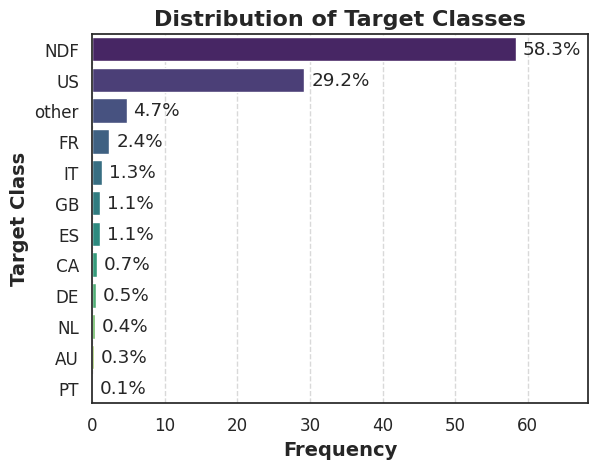

In [ ]:
ax = sns.barplot(
    data=target_distribution_df,
    x='Frequency',
    y='Target Class',
    palette='viridis',
    hue='Target Class'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5)

plt.xlim(0, max(target_distribution_df['Frequency']) + 10) # Extend the x-axis

plt.title("Distribution of Target Classes")
plt.xlabel("Frequency")
plt.ylabel("Target Class")
plt.show()

## 3.2. Sesions Set Overview

In [ ]:
print(f"Sessions set shape: {sessions_df.shape}")

Sessions set shape: (10567737, 6)


In [ ]:
sessions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10567737 entries, 0 to 10567736
Data columns (total 6 columns):
 #   Column         Dtype  
---  ------         -----  
 0   user_id        object 
 1   action         object 
 2   action_type    object 
 3   action_detail  object 
 4   device_type    object 
 5   secs_elapsed   float64
dtypes: float64(1), object(5)
memory usage: 483.8+ MB


In [ ]:
sessions_df.head()

,user_id,action,action_type,action_detail,device_type,secs_elapsed
0,d1mm9tcy42,lookup,NaN,NaN,Windows Desktop,319.0
1,d1mm9tcy42,search_results,click,view_search_results,Windows Desktop,67753.0
2,d1mm9tcy42,lookup,NaN,NaN,Windows Desktop,301.0
3,d1mm9tcy42,search_results,click,view_search_results,Windows Desktop,22141.0
4,d1mm9tcy42,lookup,NaN,NaN,Windows Desktop,435.0


## 3.3. Age/Gender Buckets Set Overview

In [ ]:
print(f"Age/Gender Buckets set shape: {age_gender_df.shape}")

Age/Gender Buckets set shape: (420, 5)


In [ ]:
age_gender_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age_bucket               420 non-null    object 
 1   country_destination      420 non-null    object 
 2   gender                   420 non-null    object 
 3   population_in_thousands  420 non-null    float64
 4   year                     420 non-null    float64
dtypes: float64(2), object(3)
memory usage: 16.5+ KB


In [ ]:
age_gender_df.head()

,age_bucket,country_destination,gender,population_in_thousands,year
0,100+,AU,male,1.0,2015.0
1,95-99,AU,male,9.0,2015.0
2,90-94,AU,male,47.0,2015.0
3,85-89,AU,male,118.0,2015.0
4,80-84,AU,male,199.0,2015.0


## 3.4. Countries Set Overview

In [ ]:
print(f"Countries set shape: {countries_df.shape}")

Countries set shape: (10, 7)


In [ ]:
countries_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   country_destination            10 non-null     object 
 1   lat_destination                10 non-null     float64
 2   lng_destination                10 non-null     float64
 3   distance_km                    10 non-null     float64
 4   destination_km2                10 non-null     float64
 5   destination_language           10 non-null     object 
 6   language_levenshtein_distance  10 non-null     float64
dtypes: float64(5), object(2)
memory usage: 692.0+ bytes


In [ ]:
countries_df.head()

,country_destination,lat_destination,lng_destination,distance_km,destination_km2,destination_language,language_levenshtein_distance
0,AU,-26.853388,133.275160,15297.7440,7741220.0,eng,0.00
1,CA,62.393303,-96.818146,2828.1333,9984670.0,eng,0.00
2,DE,51.165707,10.452764,7879.5680,357022.0,deu,72.61
3,ES,39.896027,-2.487694,7730.7240,505370.0,spa,92.25
4,FR,46.232193,2.209667,7682.9450,643801.0,fra,92.06


---

## Overview Summary

**Training Set:**
  * Type Conversion:
    * `date_account_created`, `timestamp_first_active`, and `date_first_booking` have to be converted into datetime
    * `signup_flow` have to be converted into str
  * Data Leakage:
    * The missing value in `date_first_booking` and the `NDF` class in the target have the same percentage.
    * `date_first_booking` indicates data leakage because we will not get these values in production.
    * This info is obtained after the prediction so it cannot be used as a feature.
  * Target Distribution:
    * The target variable is highly imbalanced. $\rightarrow$ class weighting + stratified K-Fold cross-validation
  
**Sessions Set:**
  * One-to-many relation.
  * Potenial features:
    * total time spent, number of unique actions taken, number of used devices, most used device

**Countries Set:**
  * distance_km and language_levenshtein_distance can be used for ranking

**Age/Gender Set:**
  * Can be ignored

---

# 4. Training Set - Exploratory Data Analysis (EDA)

## 4.1. Missing Values

In [ ]:
missing_train = (train_df.isnull().sum() / len(train_df)) * 100
missing_train_df = missing_train[missing_train > 0].sort_values(ascending=False).reset_index()
missing_train_df.columns = ['Feature', 'Missing Percentage']
missing_train_df

,Feature,Missing Percentage
0,date_first_booking,58.347349
1,age,41.222576
2,first_affiliate_tracked,2.841402


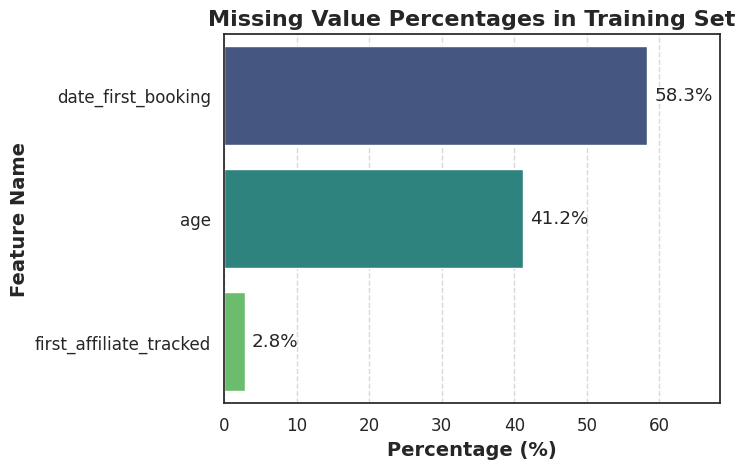

In [ ]:
ax = sns.barplot(
    data=missing_train_df,
    x='Missing Percentage',
    y='Feature',
    palette='viridis',
    hue='Feature'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5)

plt.xlim(0, max(missing_train_df['Missing Percentage']) + 10) # Extend the x-axis

plt.title("Missing Value Percentages in Training Set")
plt.xlabel("Percentage (%)")
plt.ylabel("Feature Name")
plt.show()

## 4.2. Duplicates

In [ ]:
train_df.duplicated().sum()

np.int64(0)

In [ ]:
age_gender_df.duplicated().sum()

np.int64(0)

In [ ]:
countries_df.duplicated().sum()

np.int64(0)

## 4.3. Univariate Analysis

In [ ]:
train_df['signup_flow'] = train_df['signup_flow'].astype(str)
test_df['signup_flow'] = test_df['signup_flow'].astype(str)

In [ ]:
def explore_feature(df, column_name):
    """
    Performs univariate analysis on a single DataFrame column.
    """
    print(f"===== Feature ({column_name}): =====")

    # Missing Values
    missing_values = df[column_name].isnull().sum()
    missing_percent = (missing_values / len(df)) * 100
    print(f"Missing Values: {missing_values} ({missing_percent:.2f}%)")
    print("-" * 30)

    # Check Data Type and Plot accordingly
    if pd.api.types.is_numeric_dtype(df[column_name]):
        # Numeric Feature -> descriptive stats and histogram
        print("Data Type: Numeric")
        display(df[column_name].describe())

        plt.figure(figsize=(10, 4))
        sns.histplot(df[column_name].dropna(), kde=True, bins=30)
        plt.title(f"Distribution of {column_name}")
        plt.xlabel(column_name)
        plt.ylabel("Frequency")
        plt.show()

    else:
        # Categorical Feature -> value counts, percentages, and a bar chart
        print("Data Type: Categorical")

        cardinality = df[column_name].nunique()
        print(f"Cardinality: {cardinality}")

        value_counts = df[column_name].value_counts(dropna=False)
        value_percentages = df[column_name].value_counts(normalize=True, dropna=False) * 100

        summary_df = pd.DataFrame({
            'Count': value_counts,
            'Percentage': value_percentages
        })

        display(summary_df)

        plt.figure(figsize=(12, 5))

        plot_data = summary_df.reset_index()
        ax = sns.barplot(
            data=plot_data,
            x='Percentage',
            y=plot_data.columns[0],
            palette='viridis',
            hue=plot_data.columns[0],
            legend=False
        )

        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f%%', padding=3)

        x_min, x_max = ax.get_xlim()
        ax.set_xlim(x_min, x_max +10)

        plt.title(f"Categories in {column_name}")
        plt.xlabel("Percentage")
        plt.ylabel(column_name)
        plt.show()
    print("\n" + "="*50 + "\n")

In [ ]:
train_df.columns

Index(['id', 'date_account_created', 'timestamp_first_active',
       'date_first_booking', 'gender', 'age', 'signup_method', 'signup_flow',
       'language', 'affiliate_channel', 'affiliate_provider',
       'first_affiliate_tracked', 'signup_app', 'first_device_type',
       'first_browser', 'country_destination'],
      dtype='object')

===== Feature (gender): =====
Missing Values: 0 (0.00%)
------------------------------
Data Type: Categorical
Cardinality: 4


,Count,Percentage
gender,,
-unknown-,95688,44.829024
FEMALE,63041,29.534179
MALE,54440,25.504683
OTHER,282,0.132115


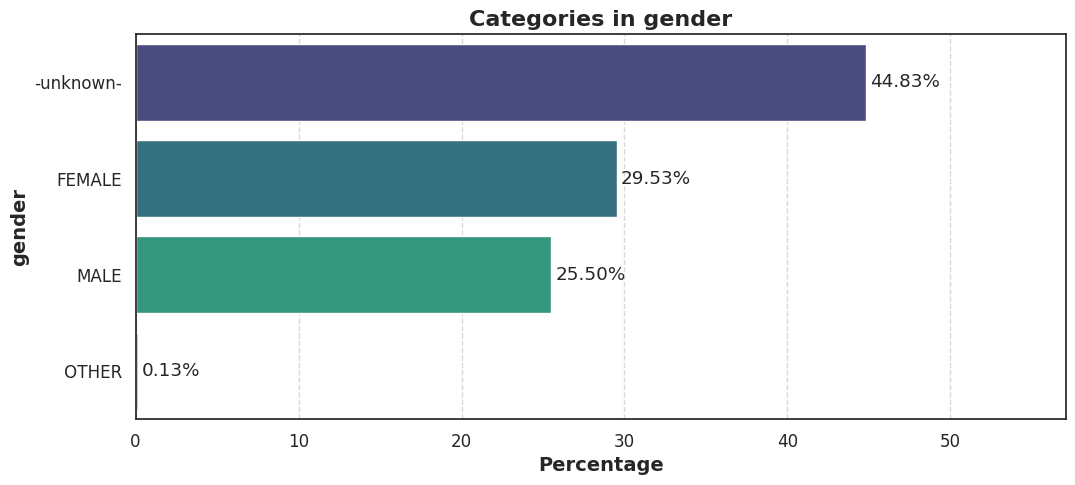



===== Feature (age): =====
Missing Values: 87990 (41.22%)
------------------------------
Data Type: Numeric


,age
count,125461.000000
mean,49.668335
std,155.666612
min,1.000000
25%,28.000000
50%,34.000000
75%,43.000000
max,2014.000000


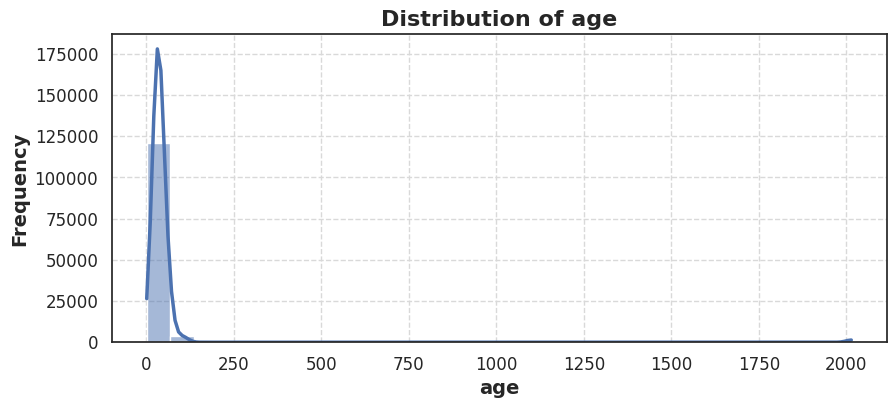



===== Feature (signup_method): =====
Missing Values: 0 (0.00%)
------------------------------
Data Type: Categorical
Cardinality: 3


,Count,Percentage
signup_method,,
basic,152897,71.630960
facebook,60008,28.113244
google,546,0.255796


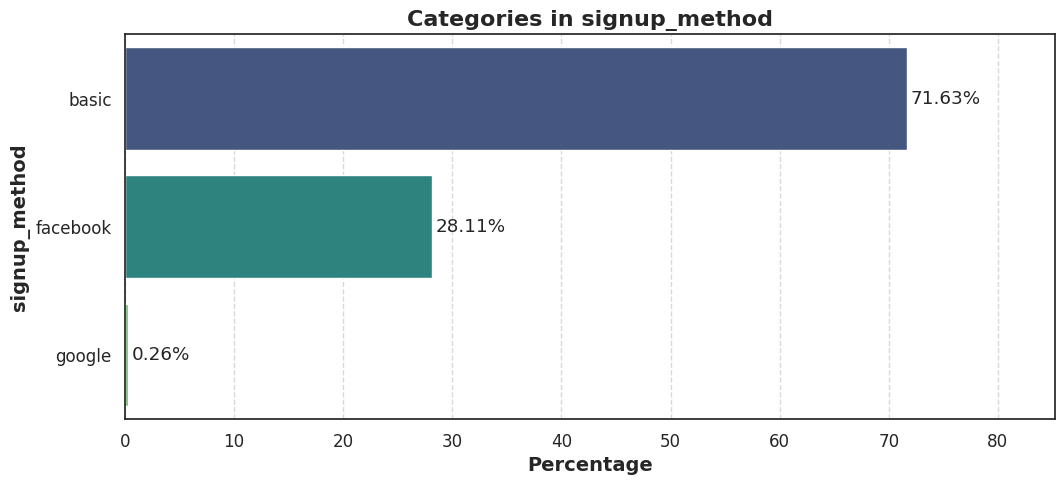



===== Feature (signup_flow): =====
Missing Values: 0 (0.00%)
------------------------------
Data Type: Categorical
Cardinality: 17


,Count,Percentage
signup_flow,,
0,164739,77.178837
25,14659,6.867618
12,9329,4.370558
3,8822,4.133033
2,6881,3.223691
24,4328,2.027632
23,2835,1.328174
1,1047,0.490511
6,301,0.141016


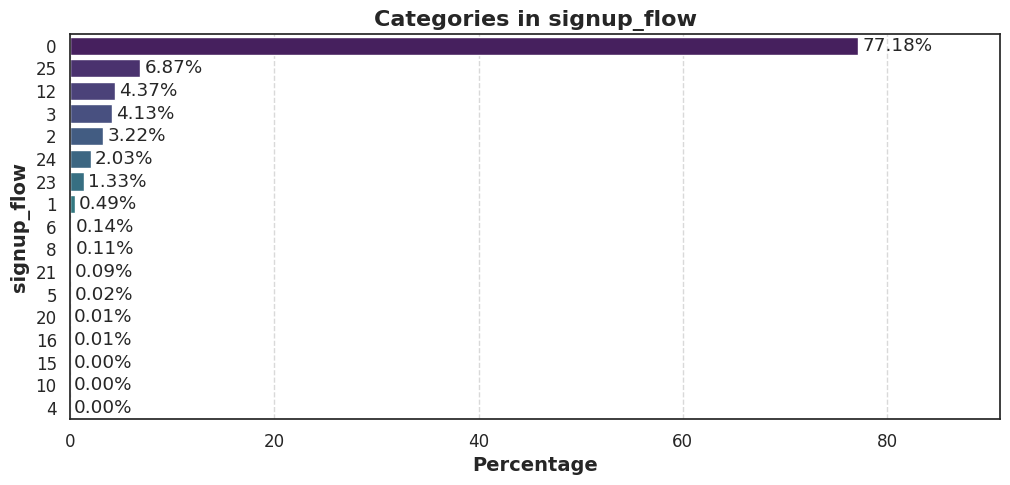



===== Feature (language): =====
Missing Values: 0 (0.00%)
------------------------------
Data Type: Categorical
Cardinality: 25


,Count,Percentage
language,,
en,206314,96.656375
zh,1632,0.764578
fr,1172,0.549072
es,915,0.428670
ko,747,0.349963
de,732,0.342936
it,514,0.240805
ru,389,0.182243
pt,240,0.112438


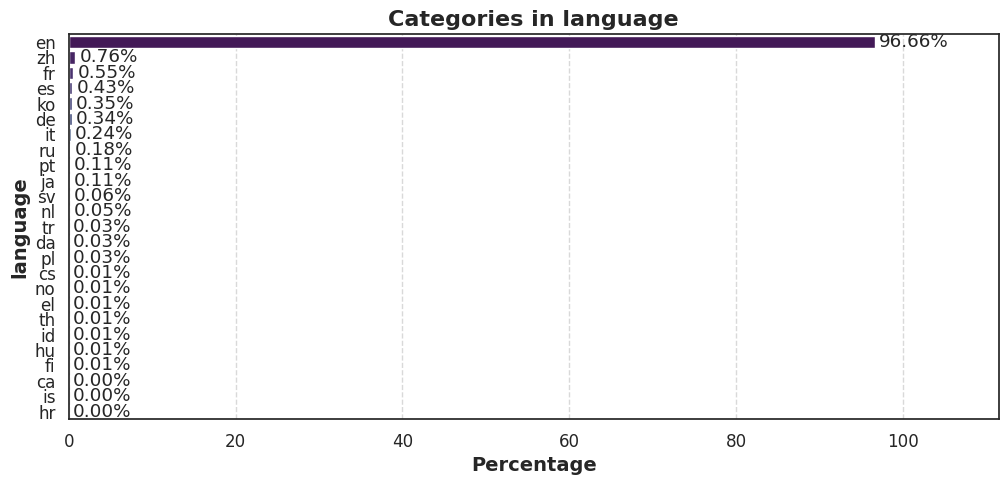



===== Feature (affiliate_channel): =====
Missing Values: 0 (0.00%)
------------------------------
Data Type: Categorical
Cardinality: 8


,Count,Percentage
affiliate_channel,,
direct,137727,64.523942
sem-brand,26045,12.201864
sem-non-brand,18844,8.828256
other,8961,4.198153
seo,8663,4.058543
api,8167,3.826171
content,3948,1.849605
remarketing,1096,0.513467


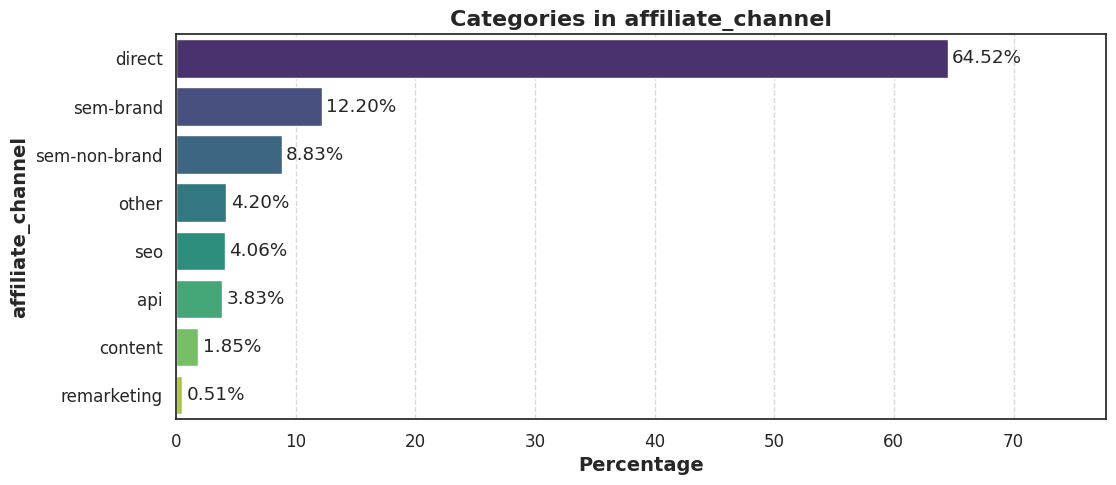



===== Feature (affiliate_provider): =====
Missing Values: 0 (0.00%)
------------------------------
Data Type: Categorical
Cardinality: 18


,Count,Percentage
affiliate_provider,,
direct,137426,64.382926
google,51693,24.217736
other,12549,5.879101
craigslist,3471,1.626134
bing,2328,1.090648
facebook,2273,1.064881
vast,829,0.388380
padmapper,768,0.359802
facebook-open-graph,545,0.255328


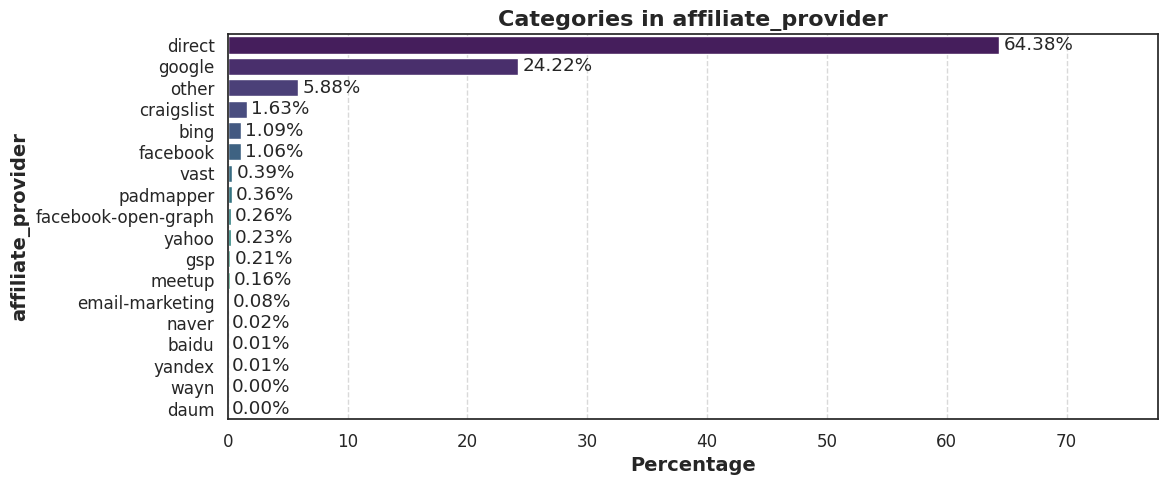



===== Feature (first_affiliate_tracked): =====
Missing Values: 6065 (2.84%)
------------------------------
Data Type: Categorical
Cardinality: 7


,Count,Percentage
first_affiliate_tracked,,
untracked,109232,51.174274
linked,46287,21.685071
omg,43982,20.605197
tracked-other,6156,2.884034
NaN,6065,2.841402
product,1556,0.728973
marketing,139,0.065120
local ops,34,0.015929


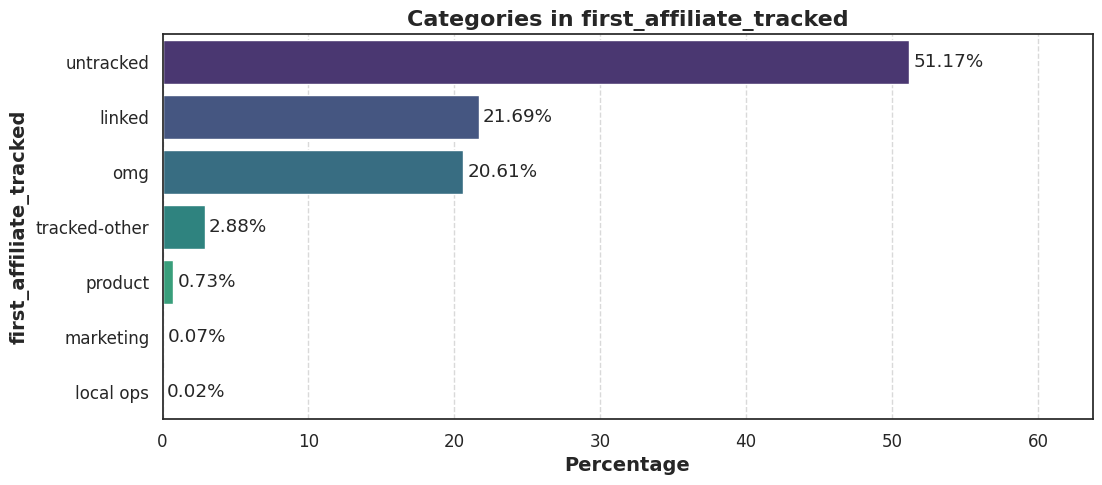



===== Feature (signup_app): =====
Missing Values: 0 (0.00%)
------------------------------
Data Type: Categorical
Cardinality: 4


,Count,Percentage
signup_app,,
Web,182717,85.601379
iOS,19019,8.910242
Moweb,6261,2.933226
Android,5454,2.555153


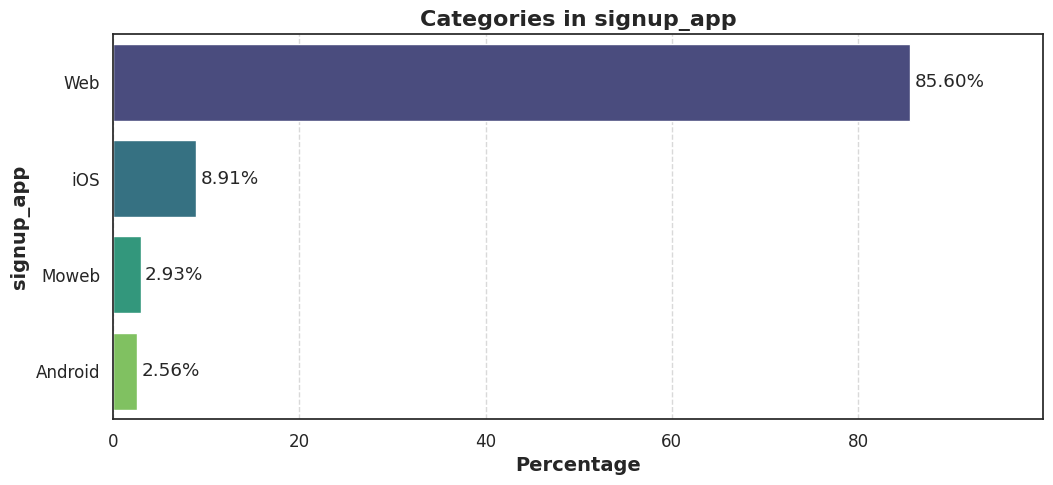



===== Feature (first_device_type): =====
Missing Values: 0 (0.00%)
------------------------------
Data Type: Categorical
Cardinality: 9


,Count,Percentage
first_device_type,,
Mac Desktop,89600,41.976847
Windows Desktop,72716,34.066835
iPhone,20759,9.725417
iPad,14339,6.717701
Other/Unknown,10667,4.997400
Android Phone,2803,1.313182
Android Tablet,1292,0.605291
Desktop (Other),1199,0.561721
SmartPhone (Other),76,0.035605


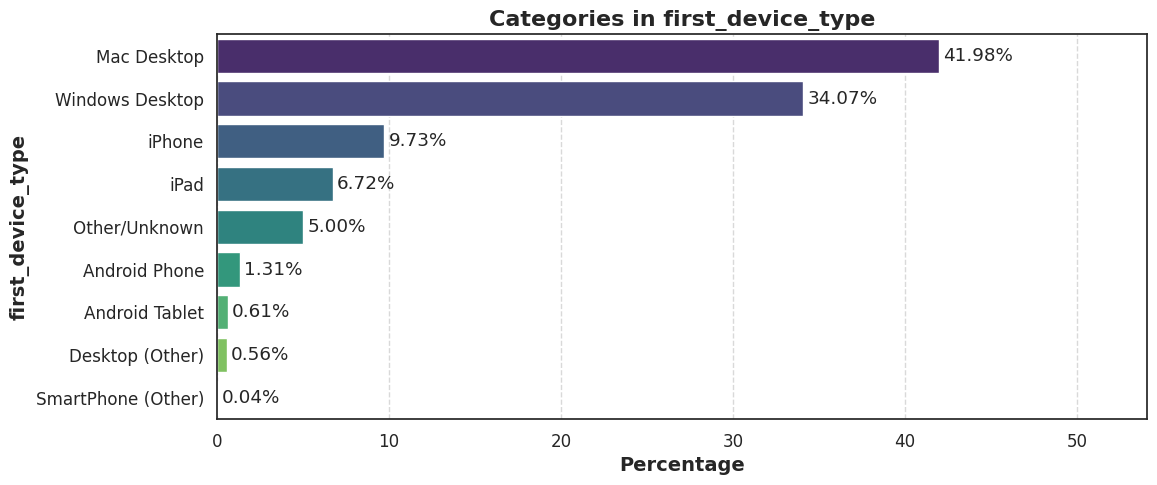



===== Feature (first_browser): =====
Missing Values: 0 (0.00%)
------------------------------
Data Type: Categorical
Cardinality: 52


,Count,Percentage
first_browser,,
Chrome,63845,29.910846
Safari,45169,21.161297
Firefox,33655,15.767085
-unknown-,27266,12.773892
IE,21068,9.870181
Mobile Safari,19274,9.029707
Chrome Mobile,1270,0.594984
Android Browser,851,0.398686
AOL Explorer,245,0.114780


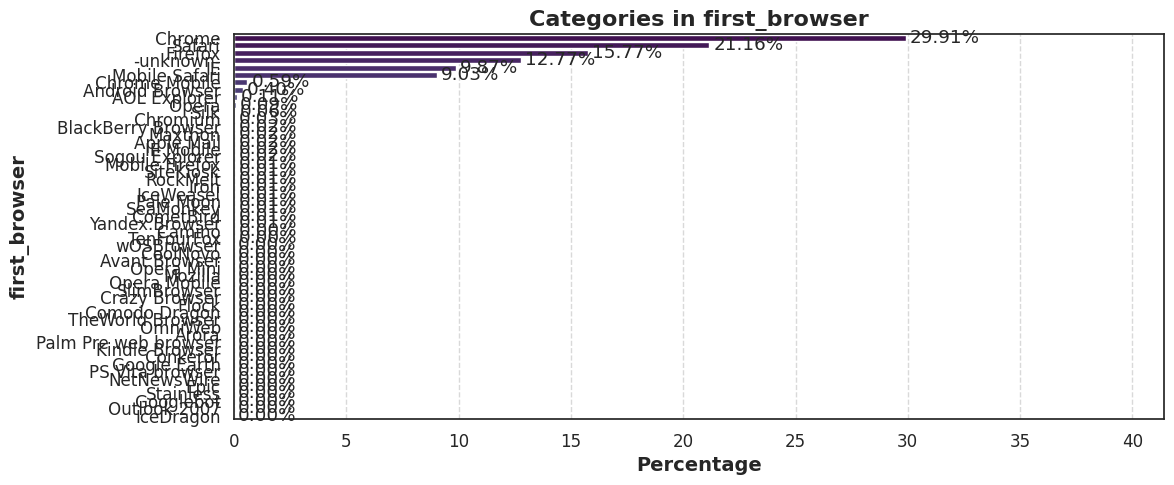



===== Feature (country_destination): =====
Missing Values: 0 (0.00%)
------------------------------
Data Type: Categorical
Cardinality: 12


,Count,Percentage
country_destination,,
NDF,124543,58.347349
US,62376,29.222632
other,10094,4.728954
FR,5023,2.353233
IT,2835,1.328174
GB,2324,1.088774
ES,2249,1.053638
CA,1428,0.669006
DE,1061,0.497070


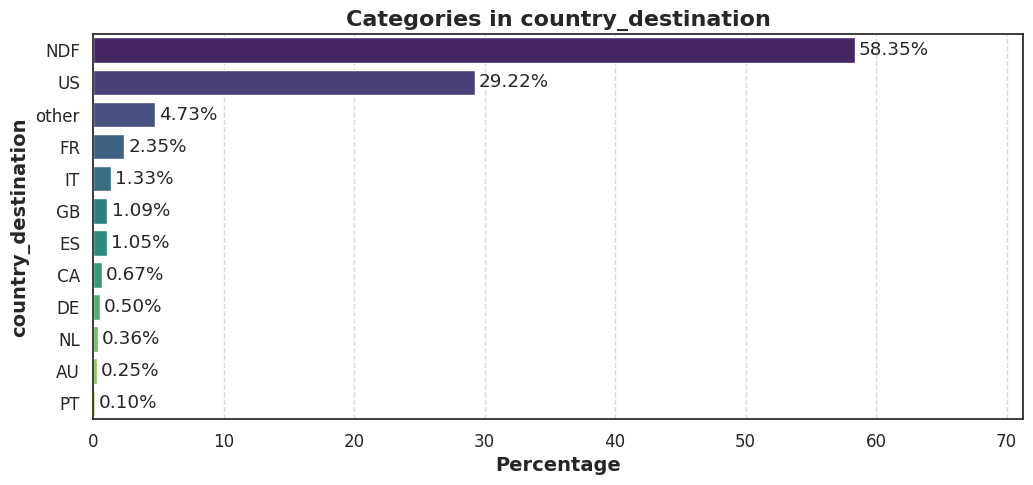

In [ ]:
train_cols_to_explore =[col for col in train_df.columns if col not in [
    'id', 'date_account_created', 'timestamp_first_active', 'date_first_booking', 'date_first_booking'
    ]]

for feature in train_cols_to_explore:
    explore_feature(train_df, feature)

**Missing Values:**
  * `date_first_booking` has 58.3% NaNs
  * `first_affiliate_tracked` has 2.8% NaNs
  * `age` has 41.2% NaNs
  * `gender` has 44.8% "-unknown-"

**Invalid Values:**
  * `age` has invalid values such as 2014 and 1

**Bucketing:**
  * `first_affiliate_tracked`
  * `age`
  * `signup_flow`
    * I couldn't find the mapping for the `signup_flow` codes
  * `language`
  * `affiliate_channel`
  * `affiliate_provider`
  * `signup_app`
  * `first_device_type`
  * `first_browser`


## 4.4. Bivariate Analysis

### 4.4.1. Categorical Features vs. Target

In [ ]:
def bivariate_analysis(df, feature, target='country_destination'):
    print(f"===== Bivariate Analysis: {feature} vs. {target} =====")

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # --- Plot 1: The Booking Rate (Binary Conversion) ---
    # Create temporary binary target: 0 if NDF, 1 if they booked a destination
    df_temp = df.copy()
    df_temp['is_booking'] = (df_temp[target] != 'NDF').astype(int)

    # Calculate conversion rate per category
    conversion_rates = df_temp.groupby(feature)['is_booking'].mean() * 100
    conversion_rates = conversion_rates.sort_values(ascending=False)

    sns.barplot(x=conversion_rates.index, y=conversion_rates.values, ax=axes[0], palette='viridis', hue=conversion_rates.index, legend=False)
    axes[0].set_title(f"Booking Conversion Rate by {feature}", pad=15)
    axes[0].set_ylabel("Booking Rate (%)")
    axes[0].set_xlabel(feature)
    axes[0].set_ylim(0, 100)
    axes[0].set_xticks(range(len(conversion_rates.index)))
    axes[0].set_xticklabels(conversion_rates.index, rotation=45, ha='right')

    # Add labels
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt='%.1f%%', padding=5, rotation=90)

    # --- Plot 2: Destination Heatmap ---
    # Calculate crosstab percentages
    crosstab_df = pd.crosstab(df[feature], df[target], normalize='index') * 100

    # Optional: Reorder columns to put NDF and US first, then the rest
    cols = ['NDF', 'US'] + [c for c in crosstab_df.columns if c not in ['NDF', 'US']]
    crosstab_df = crosstab_df[cols]

    sns.heatmap(crosstab_df, annot=True, fmt=".1f", cmap="Blues", cbar=False, ax=axes[1], linewidths=.5)
    axes[1].set_title(f"Destination Distribution Heatmap by {feature}", pad=15)
    axes[1].set_ylabel(feature)
    axes[1].set_xlabel("Destination Country")

    plt.tight_layout()
    plt.show()

In [ ]:
categorical_features = [feature for feature in train_cols_to_explore if feature not in ['age', 'country_destination']]
categorical_features

['gender',
 'signup_method',
 'signup_flow',
 'language',
 'affiliate_channel',
 'affiliate_provider',
 'first_affiliate_tracked',
 'signup_app',
 'first_device_type',
 'first_browser']

===== Bivariate Analysis: gender vs. country_destination =====


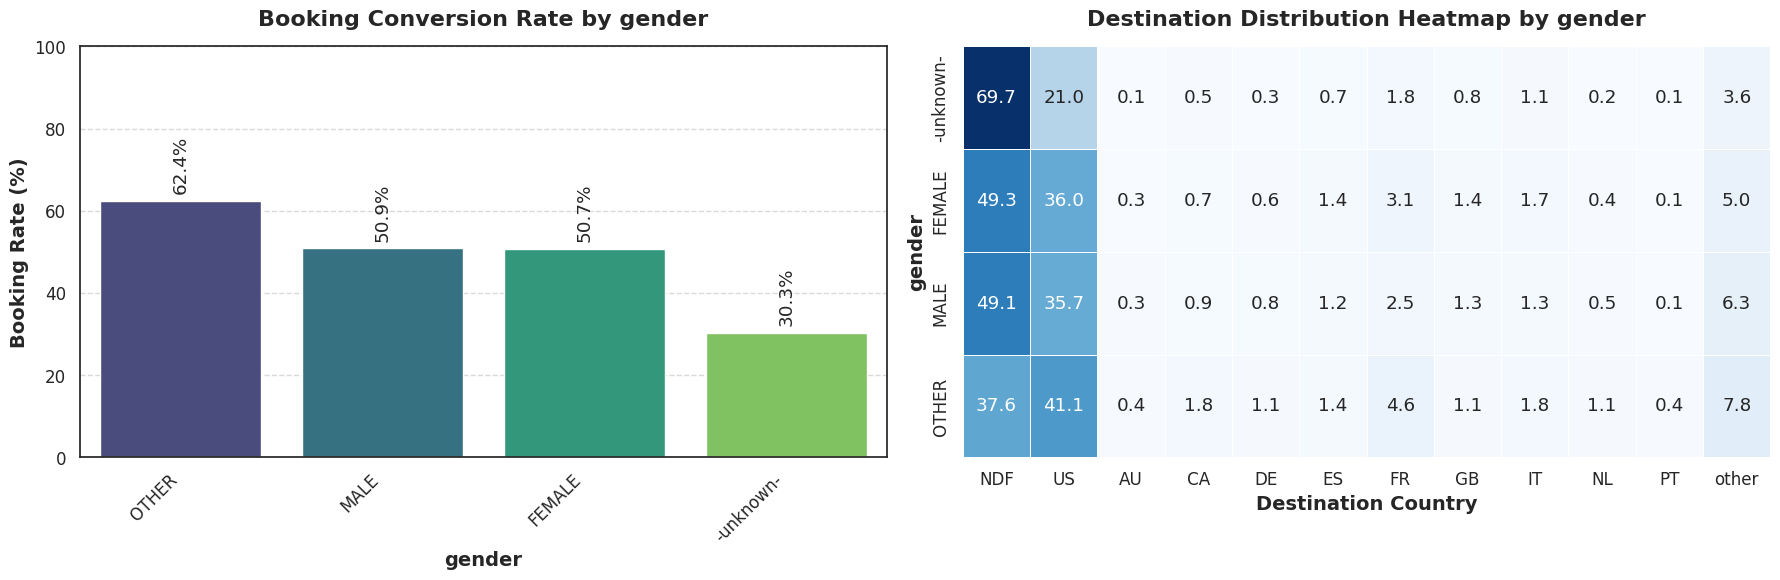

===== Bivariate Analysis: signup_method vs. country_destination =====


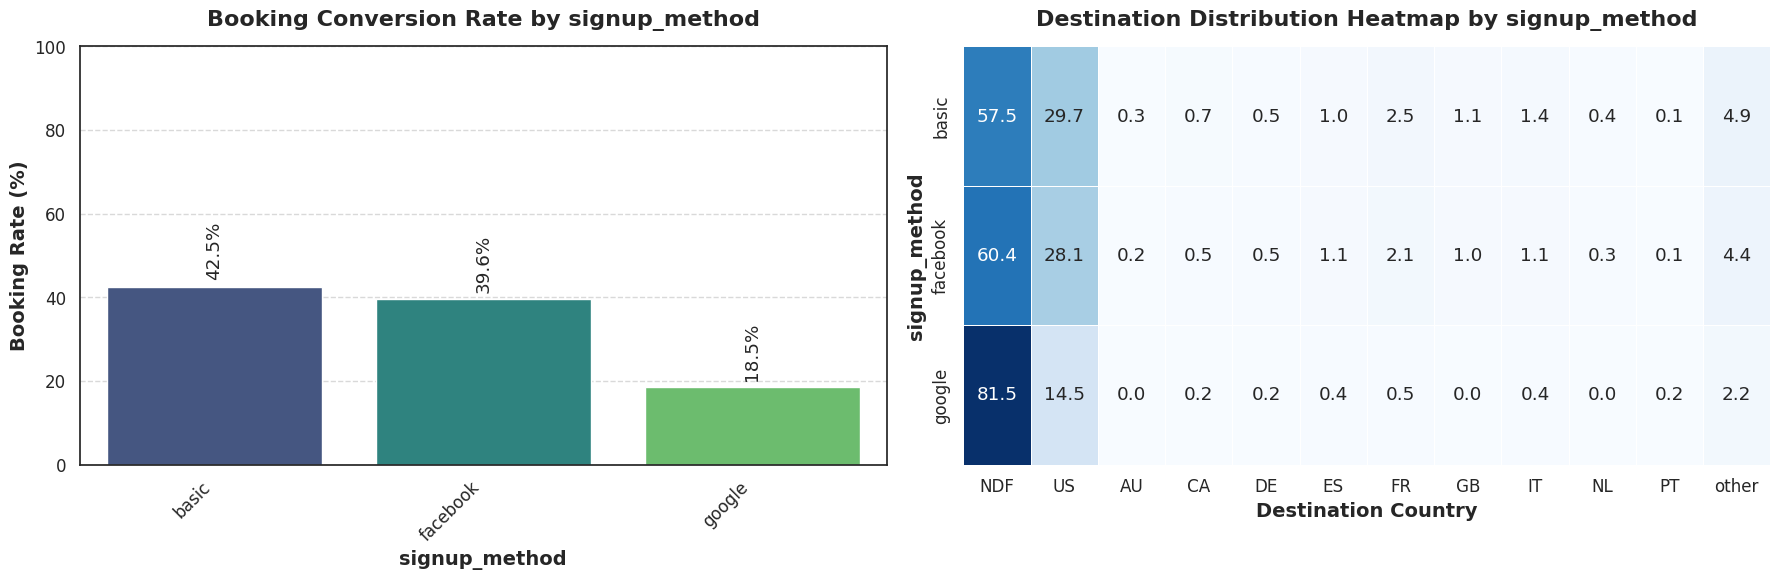

===== Bivariate Analysis: signup_flow vs. country_destination =====


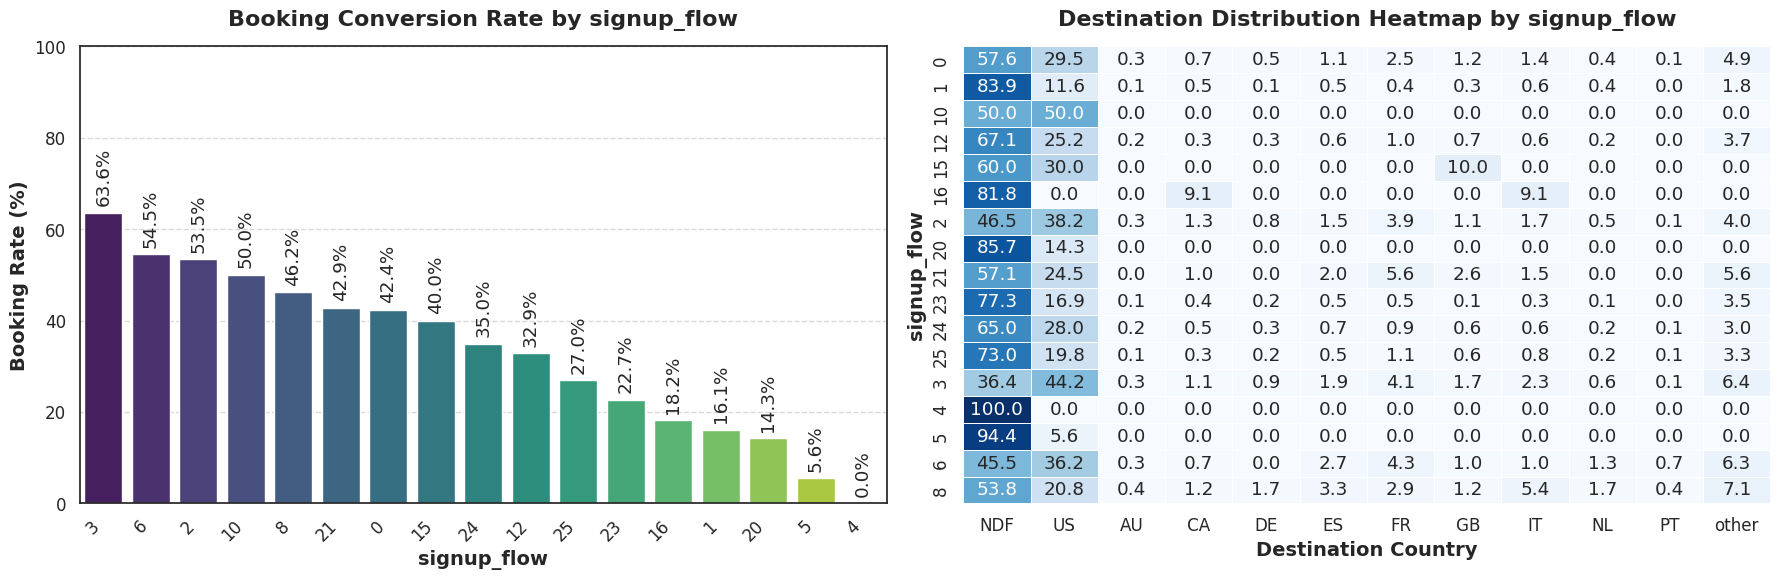

===== Bivariate Analysis: language vs. country_destination =====


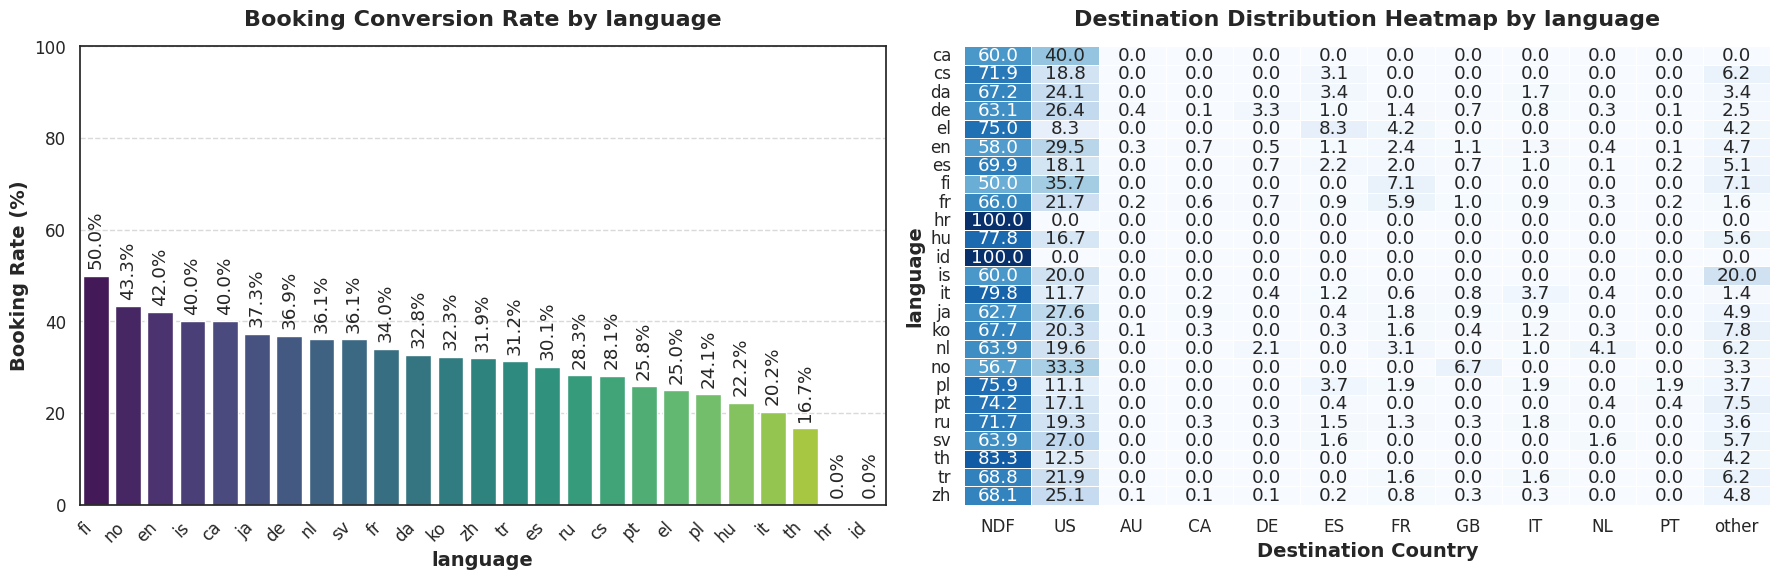

===== Bivariate Analysis: affiliate_channel vs. country_destination =====


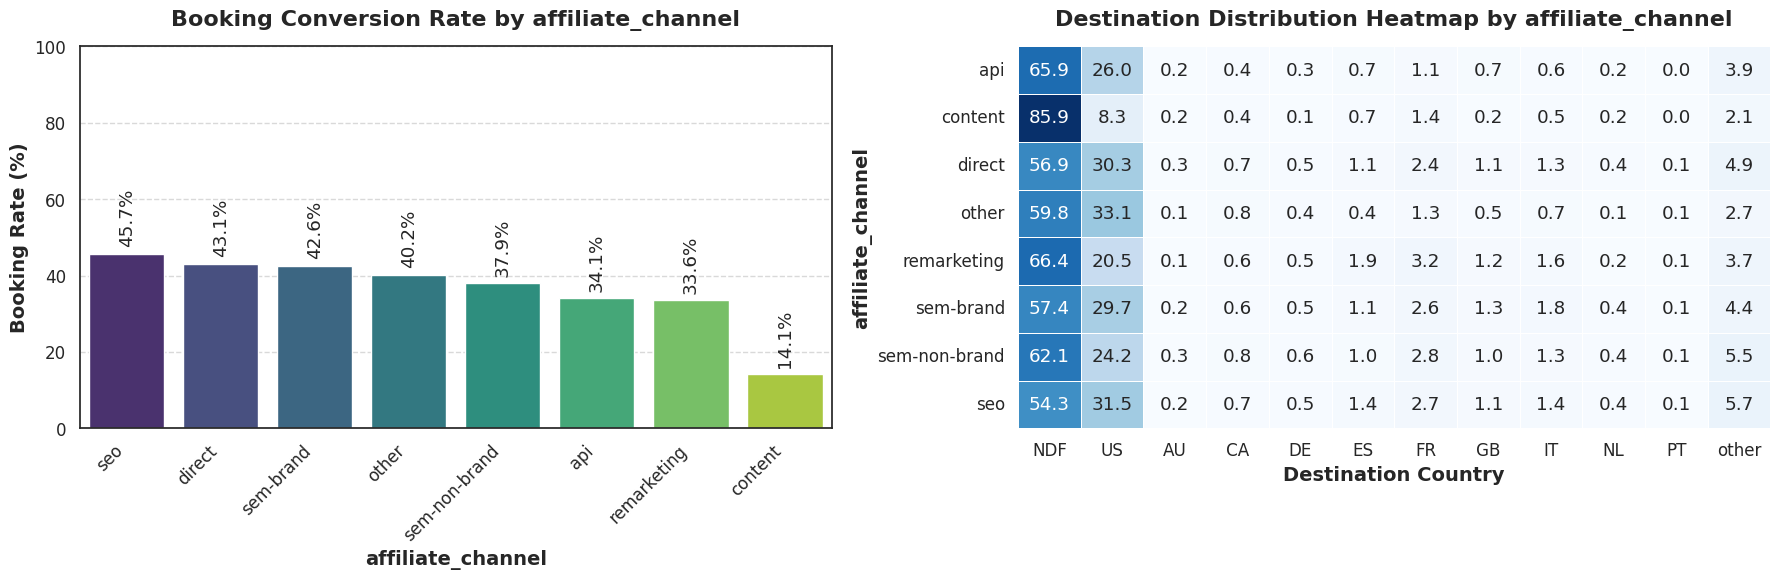

===== Bivariate Analysis: affiliate_provider vs. country_destination =====


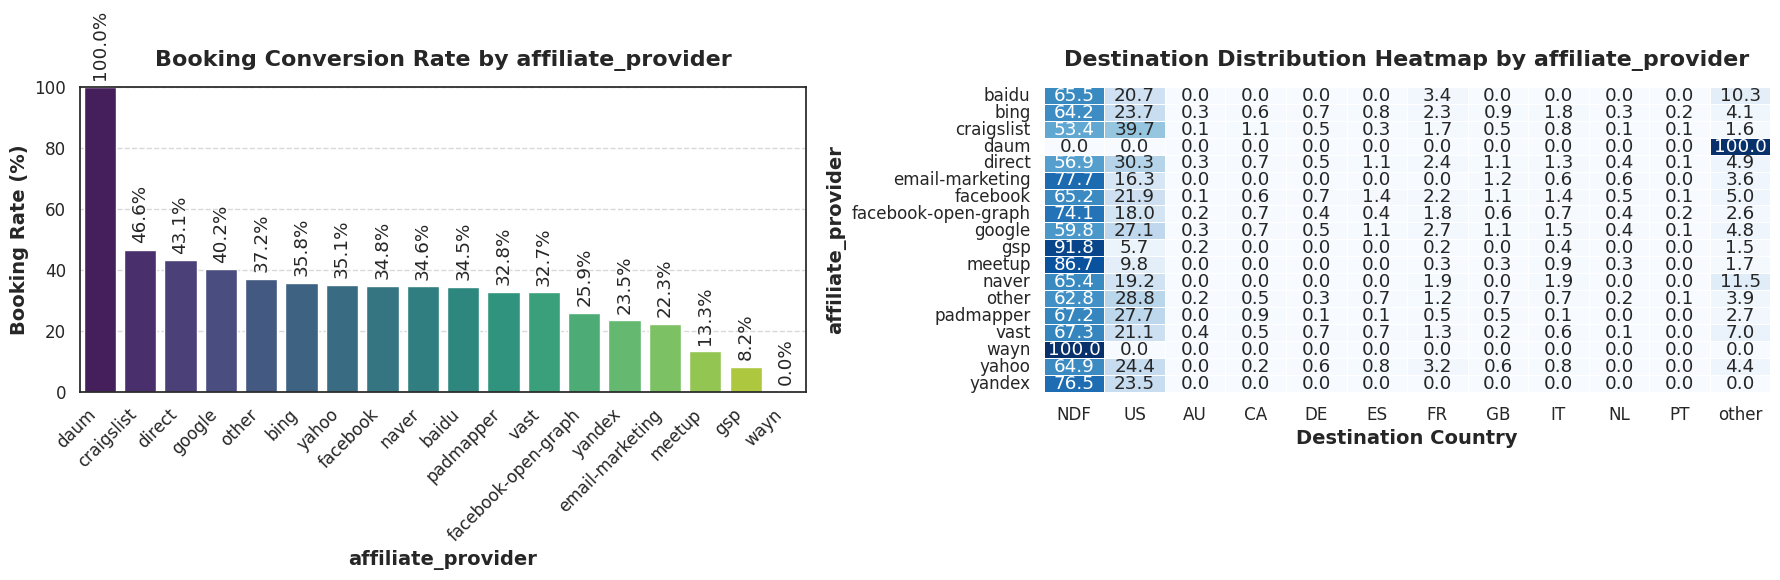

===== Bivariate Analysis: first_affiliate_tracked vs. country_destination =====


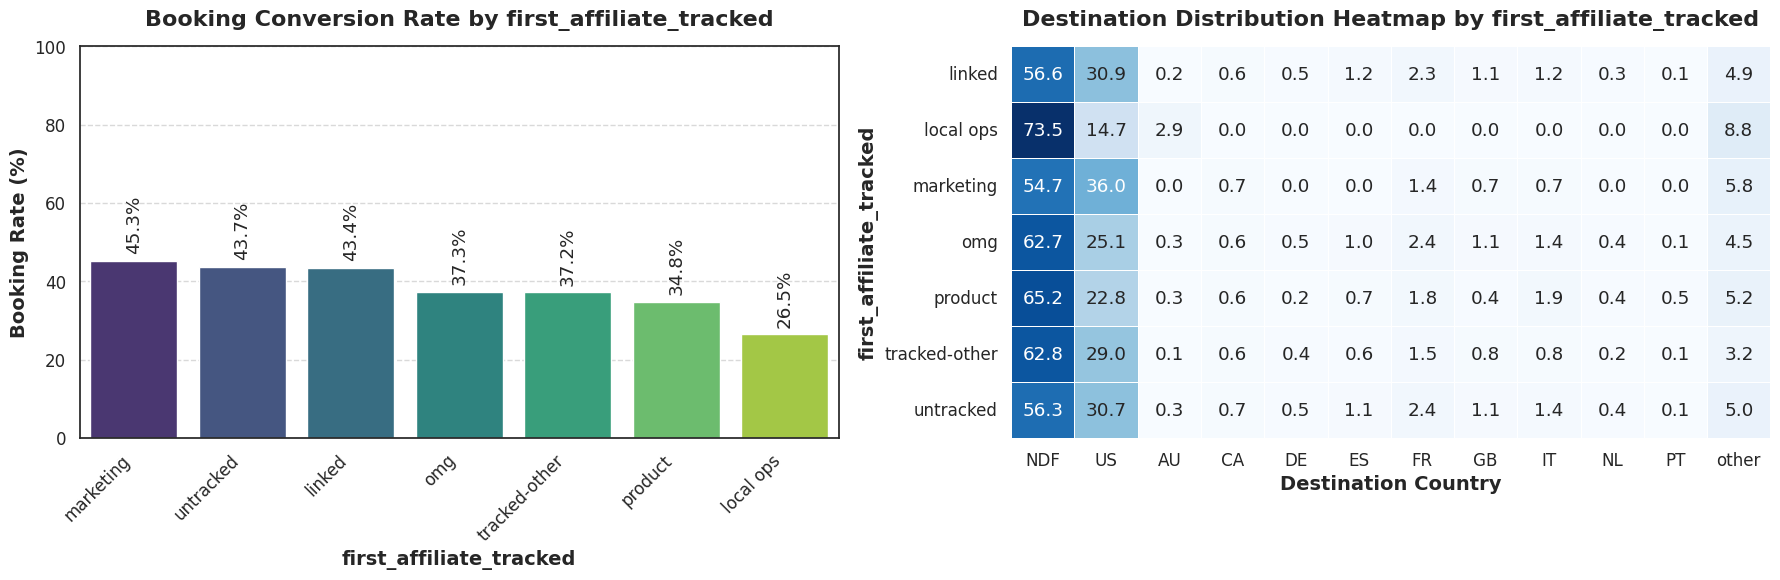

===== Bivariate Analysis: signup_app vs. country_destination =====


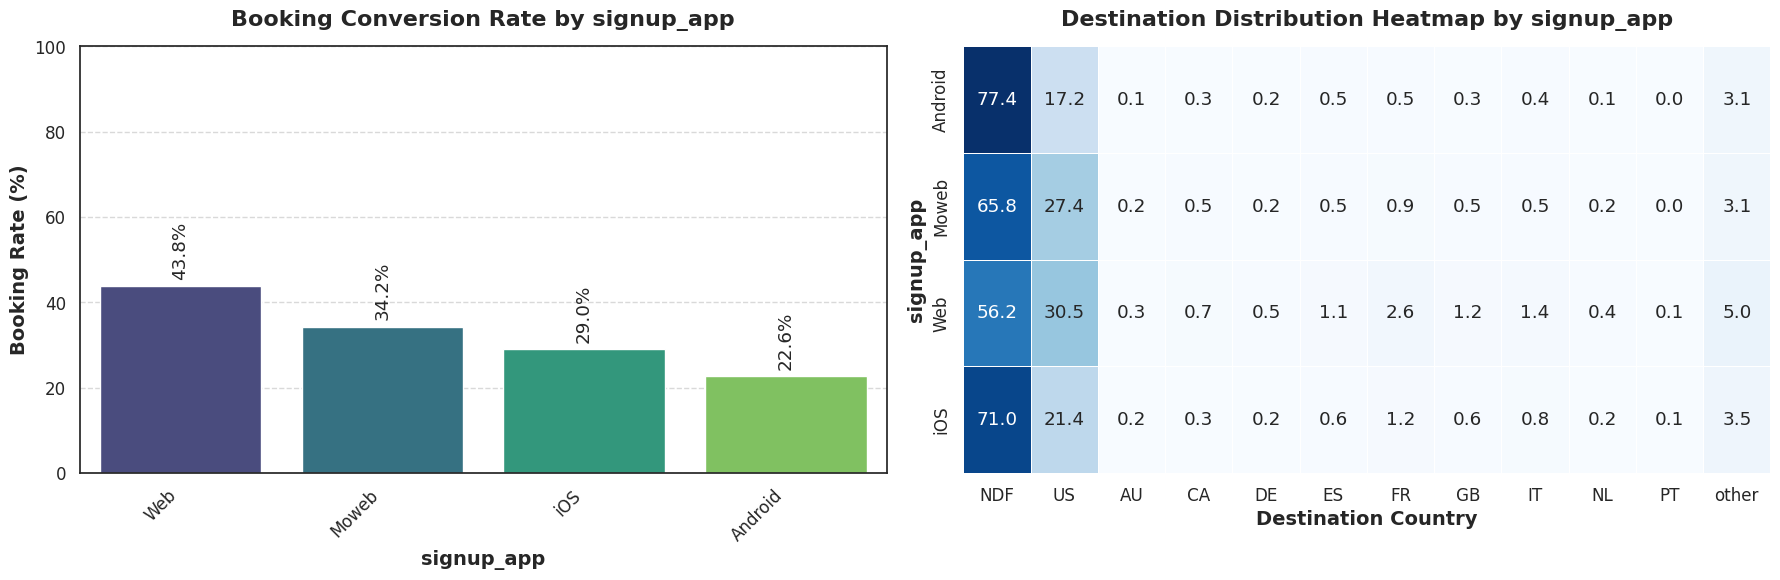

===== Bivariate Analysis: first_device_type vs. country_destination =====


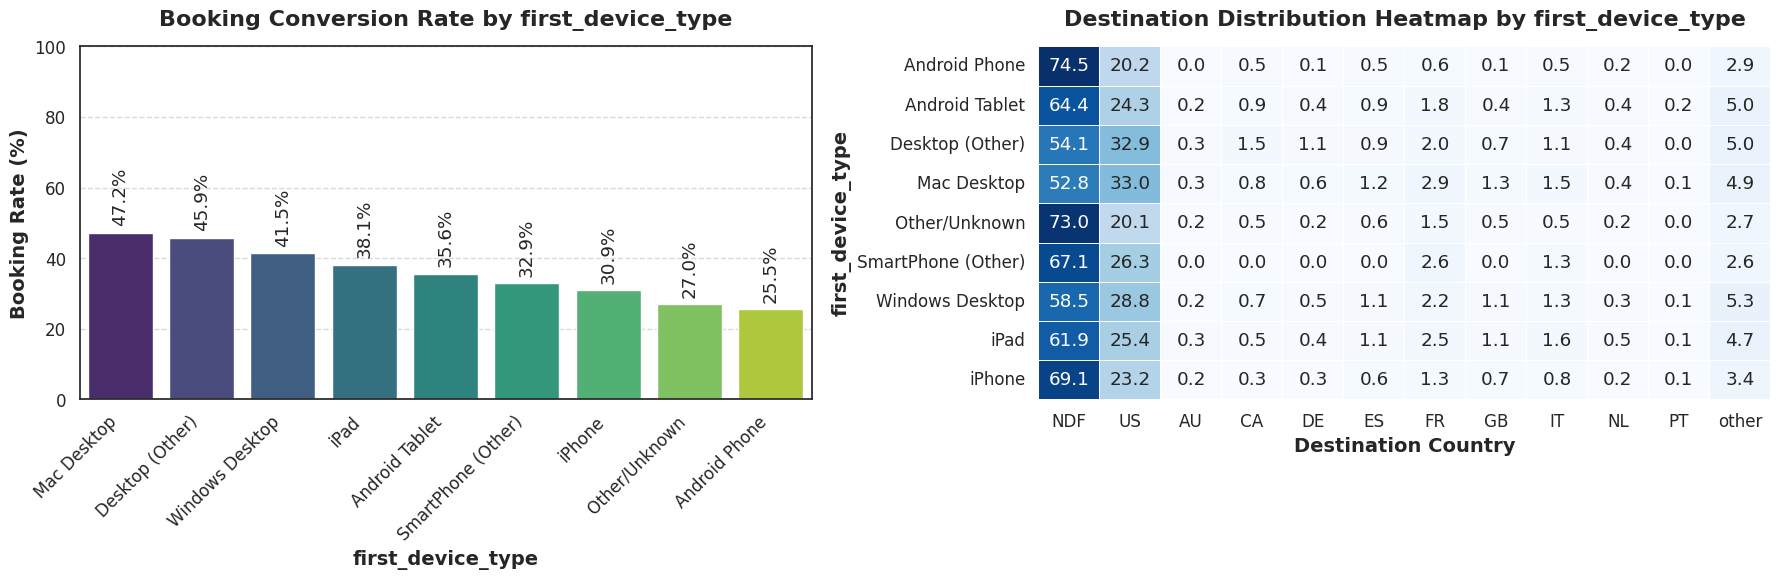

In [ ]:
# 'first_browser' is excluded due to high cardinality
for feature in categorical_features:
    if feature != 'first_browser':
        bivariate_analysis(train_df, feature)

### 4.4.2. Numerical Features vs. Target

--- Bivariate Analysis: AGE vs COUNTRY_DESTINATION ---


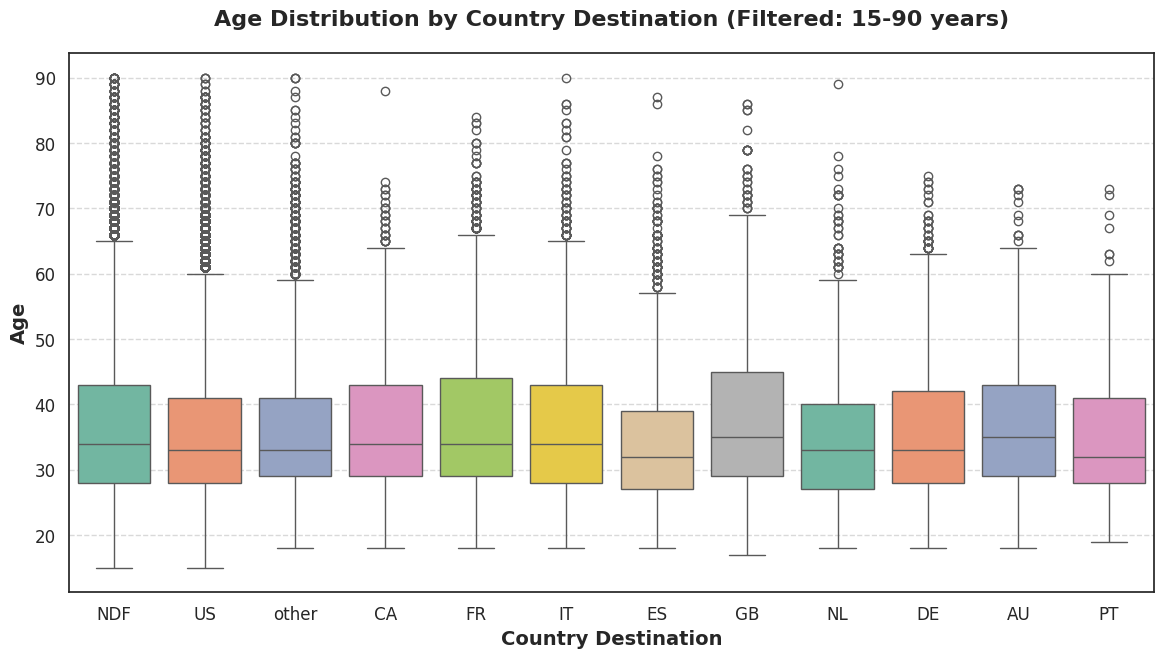

Median Age per Destination:


country_destination,ES,PT,NL,DE,other,US,CA,FR,IT,NDF,GB,AU
age,32.0,32.0,33.0,33.0,33.0,33.0,34.0,34.0,34.0,34.0,35.0,35.0


In [ ]:
print("--- Bivariate Analysis: AGE vs COUNTRY_DESTINATION ---")

# Create a temporary dataframe with filtered realistic ages for visualization purposes
temp_df = train_df[(train_df['age'] >= 15) & (train_df['age'] <= 90)].copy()

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=temp_df,
    x='country_destination',
    y='age',
    palette='Set2',
    hue='country_destination'
)

plt.title("Age Distribution by Country Destination (Filtered: 15-90 years)", pad=20)
plt.xlabel("Country Destination")
plt.ylabel("Age")
plt.show()

# Show the median age per destination
median_ages = temp_df.groupby('country_destination')['age'].median().sort_values()
print("Median Age per Destination:")
display(median_ages.to_frame().T)

* **`gender`:**
  * `-unknown-` have a massive 69.7% NDF rate. It will be kept as a separate category.
  * Although `others` has a high conversion rate, it has a small sample size.

* **`first_device_type`:**
  * Desktop users has a higher conversion rate than the phone users
    * Add new feature: `is_desktop`
  * Apple users ('Mac Desktop', 'iPad', 'iPhone') has a higher conversion rate than the other users
    * Add new feature: `is_Apple_device`
* **`affiliate_channel`:**
  * Categories can be merged into 3 buckets based on the traffic quality:
    * High_Intent_Channel: `seo`, `direct`, `sem-brand`, `other`
    * Mid_Intent_Channel: `sem-non-brand`
    * Low_Intent_Channel: `api`, `remarketing`, `content`

* **`language`:**
  * Good indicator for the minority target classes such as ER, DE, and ES.
  * Keep en, fr, es, de, it, nl, and pt separate
  * Bucket all the other languages

* **`signup_flow`:**
  * Categories can be merged into 4 buckets based on the intent level:
    * Flow_0: Flow 0 is kept alone because it has a massive sample size (77.18%) and an average booking rate of (42.4%)
    * High_Intent: Flow 3 and 2 has enough data volume to be statistically significant (4.13% and 3.22%) while also demonstrating high booking rates (63.6% and 53.5%)
    * Low_Intent_Flow: Flow 24, 12, 25, and 23 have reliable volumes (> 1%) but perform significantly worse (22% to 35%) booking range
    * Rare_Flow: Flow 1, 4, 5, 6, 8, 10, 15, 16, 20, and 21 represents less than 0.5% of the dataset. Even though a few of them (like 6 or 10) show high conversion rates, the sample size is too small to trust.

* **`affiliate_provider`:**
  * Categories can be merged into 3 buckets based on the intent level:
    * High_Intent_Provider: craigslist, direct, and google
    * Medium_Intent_Provider: other, bing, yahoo, facebook, naver, baidu, padmapper, and vast
    * Low_Intent_Provider: facebook-open-graph, yandex, email-marketing, meetup, gsp, wayn, and daum

* **`first_affiliate_tracked `:**
  * Categories can be merged into 3 buckets based on the intent level:
    * Merge tracked-other, product, marketing, and local ops into one bucket
    * Keep untracked, linked, and omg alone

* **`first_browser`:**
  * The top 6 categories (Chrome, Safari, Firefox, -unknown-, IE, and Mobile Safari) will be kept
  * The other categories will be merged into one bucket

* **`age`:**
  * The distributions are almost similar
  * The continuous age will be descritized into:
    * 15-24
    * 25-34
    * 35-44
    * 45-49
    * 50+

### 4.4.3. Cramer's V Score (Correlation)

> Cramer's V Score is built on the Chi-Square test and calculates the strength of association between two categorical variables

In [ ]:
def cramers_v(x, y):
    """Calculates Cramér's V statistic for categorical-categorical association"""

    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    # Bias correction for Cramér's V
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    # Handle edge cases where denominator might be 0
    if min((kcorr-1), (rcorr-1)) == 0:
        return 0
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))



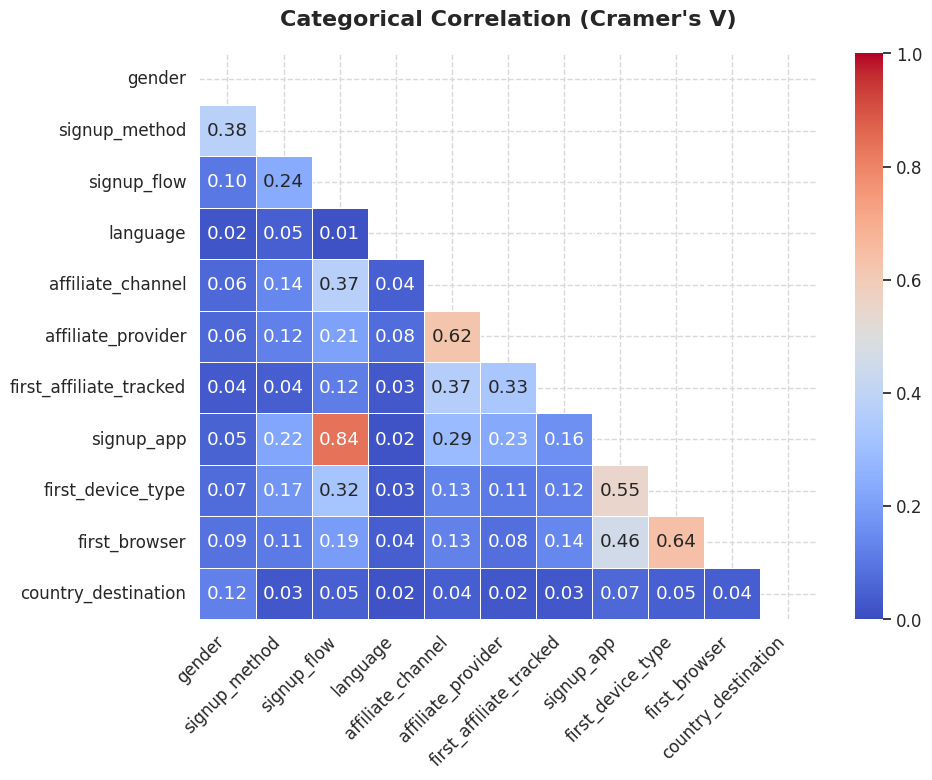

In [ ]:
carmer_vars = categorical_features + ['country_destination']

# 2. Create an empty DataFrame to hold the correlation matrix
cramers_matrix = pd.DataFrame(index=carmer_vars, columns=carmer_vars)

# 3. Calculate the association for every pair
for col1 in carmer_vars:
    for col2 in carmer_vars:
        cramers_matrix.loc[col1, col2] = cramers_v(train_df[col1], train_df[col2])

# Convert everything to float for plotting
cramers_matrix = cramers_matrix.astype(float)

# 4. Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cramers_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    mask=np.triu(np.ones_like(cramers_matrix, dtype=bool)) # Hides the upper triangle
)

plt.title("Categorical Correlation (Cramer's V)", pad=20, fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**High Correlation:**
  * `signup_flow` and `signup_app`: Some signup flow codes may be dedicated for specific signup apps.
  * `first_browser` and `first_device_type`:
    * Most of the browsers dectate the device type.
  * `affiliate_channel` and `affiliate_provider`:
    * Most of the channels dectate the provider.
  * `signup_app` and `first_device_type`:
    * Most of the signup apps dectate the device type.

However, Tree-based models do not get affected by multicolinearity.

## 4.5. Investigate Missingness

In [ ]:
temp_df = train_df.copy()
temp_df['gender'] = temp_df['gender'].replace('-unknown-', np.nan)

missing_features = ['age', 'first_affiliate_tracked', 'gender']

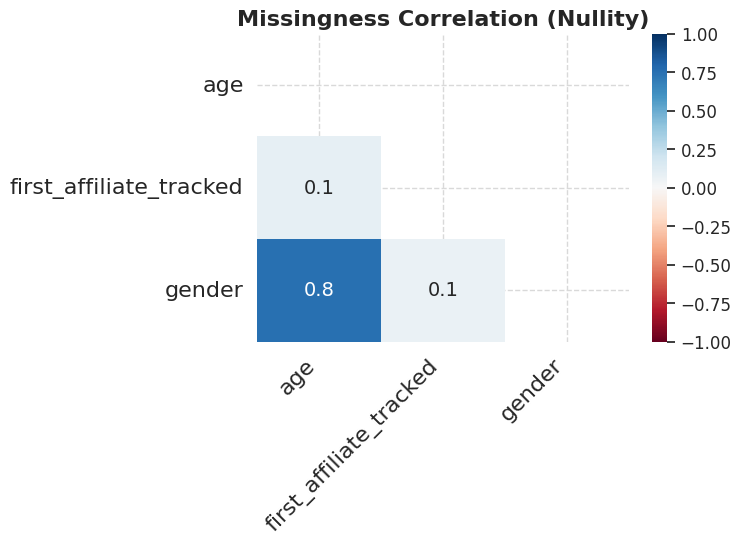

In [ ]:
msno.heatmap(temp_df[missing_features], figsize=(6, 4))
plt.title("Missingness Correlation (Nullity)")
plt.show()

In [ ]:
def plot_missing_vs_target(df, feature, target='country_destination'):

    is_missing = df[feature].isna()

    temp_df = pd.DataFrame({
        'Missing_Status': np.where(is_missing, 'Missing Data', 'Provided Data'),
        'Target': df[target]
    })

    # 100% stacked percentage summary
    dist = temp_df.groupby(['Missing_Status', 'Target']).size().unstack(fill_value=0)
    dist = dist.div(dist.sum(axis=1), axis=0) * 100

    ax = dist.T.plot(kind='bar', figsize=(14, 6))
    plt.title(f"Target Distribution: When '{feature}' is Missing vs. Provided")
    plt.ylabel("Percentage of Users")
    plt.xlabel("Destination Country")
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3, rotation=90, size=10)

    plt.ylim(0, 90)

    plt.tight_layout()
    plt.show()

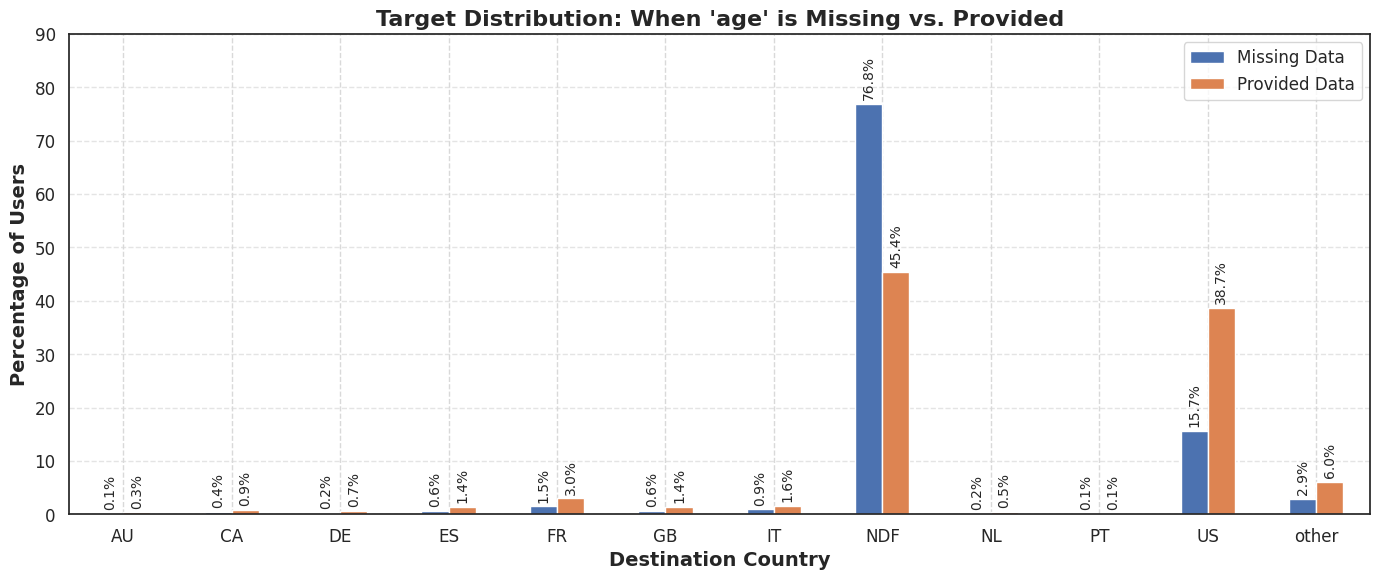

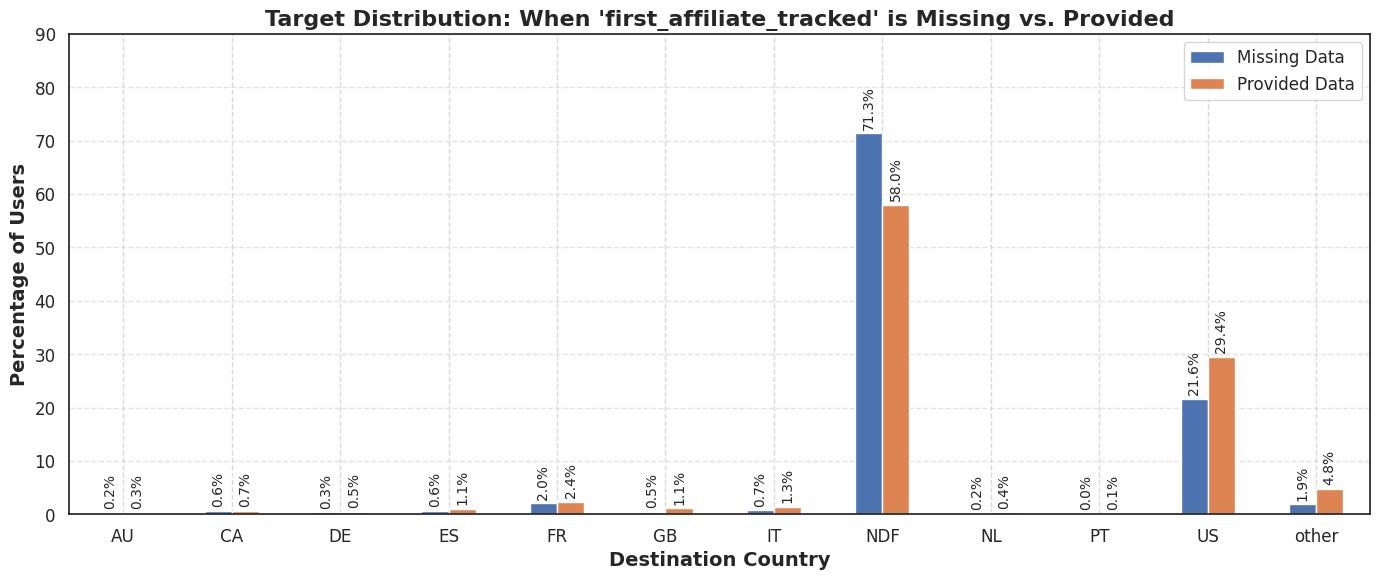

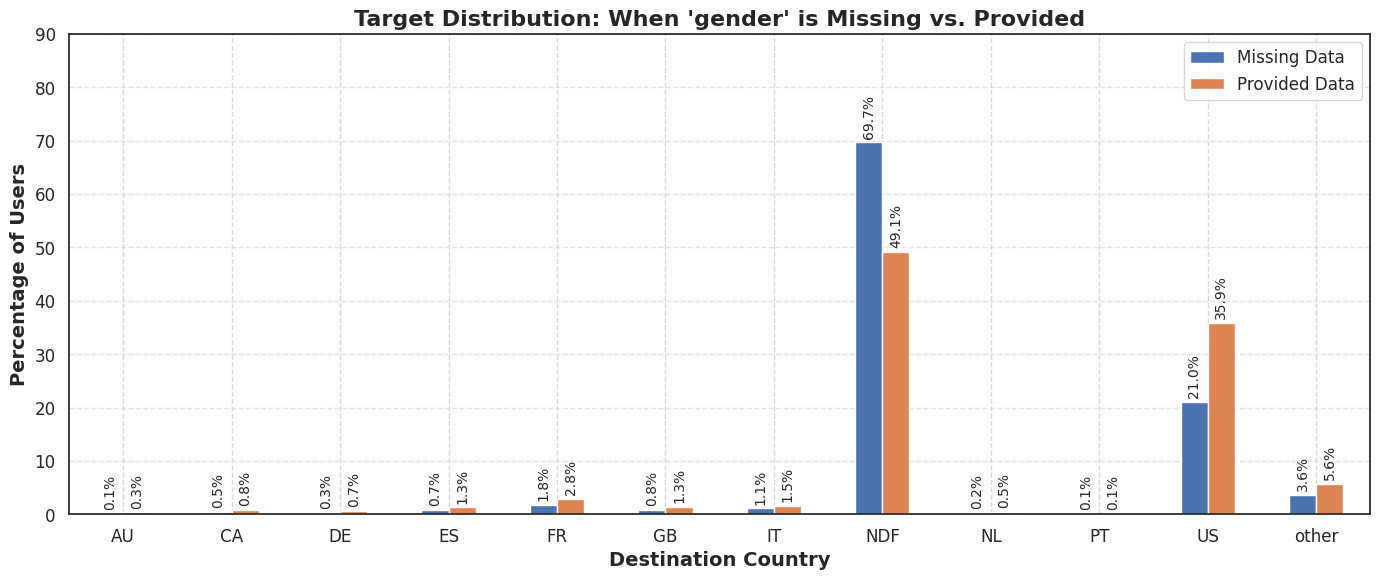

In [ ]:
for feature in missing_features:
    plot_missing_vs_target(temp_df, feature)

**Missingness Correlation:**
  * `age` and `gender`:
    * If a user refuses to provide their age, they are almost refusing to provide their gender as well.
    * This proves that this missingness is not random. It is a intended to skip the demographic questions during signup.
  
**Missing Not At Random (MNAR):**
  * The missingness in `age`, `gender`, or `first_affiliate_tracked` is a deliberate behavioral choice strongly correlated with the target variable (NDF).
  * The absence of the gender is a massive negative intent signal.
  * The "-unknown-" category in the `gender` and the missing values in `age` and `first_affiliate_tracked` wil be kept as a distinct category.



## 4.6. Outliers

In [ ]:
fig = px.box(
    train_df,
    y="age",
    title="Age Distribution"
    )
fig.update_yaxes(range=[0, 120]) # The max age is 2014 but the y-axix is cut off for clear visualization
fig.show()

In [ ]:
# The IQR Method
Q1 = train_df['age'].quantile(0.25)
Q3 = train_df['age'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q3 - 1.5 * IQR

print(f"Statistical Upper Boundary: {upper_bound}")
print(f"Statistical Lower Boundary: {lower_bound}")

# The Percentile Method
p99 = train_df['age'].quantile(0.99)
print(f"99th Percentile: {p99}")

Statistical Upper Boundary: 65.5
Statistical Lower Boundary: 20.5
99th Percentile: 105.0


In [ ]:
filtered_age_df = train_df[train_df['age'] <= 200]

fig = px.histogram(
    filtered_age_df,
    x="age",
    nbins=100,
    title="Age Distribution (Ages <= 200)",
    marginal="box",
    opacity=0.75
)

fig.update_layout(
    xaxis_title="Age",
    yaxis_title="Number of Users",
    bargap=0.05,
    hovermode="x"
)

fig.show()

In [ ]:
len(train_df[train_df['age'] < 15])

57

In [ ]:
train_df[train_df['age'] < 15]

,id,date_account_created,timestamp_first_active,date_first_booking,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_device_type,first_browser,country_destination
193,3qsa4lo7eg,2010-03-06,20100306184019,2010-03-08,FEMALE,5.0,basic,3,en,sem-non-brand,google,NaN,Web,Other/Unknown,-unknown-,FR
482,rzhouzy2ok,2010-04-29,20100429161617,2010-04-29,FEMALE,5.0,facebook,0,en,other,craigslist,tracked-other,Web,Mac Desktop,Safari,IT
642,5yatk13sko,2010-05-20,20100520212258,NaN,-unknown-,5.0,facebook,2,en,direct,direct,NaN,Web,Other/Unknown,-unknown-,NDF
660,593gkcul8c,2010-05-24,20100524042738,NaN,FEMALE,5.0,facebook,2,en,direct,direct,untracked,Web,Mac Desktop,Safari,NDF
776,tu2iorbez0,2010-06-07,20100607173548,NaN,MALE,5.0,facebook,2,en,other,craigslist,untracked,Web,Mac Desktop,Safari,NDF
780,zgxbrsgjcn,2010-06-07,20100607220745,NaN,-unknown-,5.0,basic,0,fr,direct,direct,linked,Web,iPhone,Mobile Safari,NDF
781,4395zaz8fe,2010-06-07,20100607235738,NaN,MALE,5.0,facebook,2,en,content,google,linked,Web,Windows Desktop,IE,NDF
812,s8wb7qdjqc,2010-06-14,20100614013701,2010-06-18,-unknown-,5.0,facebook,2,en,sem-non-brand,google,untracked,Web,Windows Desktop,IE,US
816,ceum3xl08h,2010-06-14,20100614171620,NaN,MALE,5.0,facebook,2,en,direct,direct,NaN,Web,Other/Unknown,-unknown-,NDF
837,s016mu0c9w,2010-06-16,20100616151810,NaN,FEMALE,5.0,facebook,2,en,direct,direct,untracked,Web,Mac Desktop,Chrome,NDF


In [ ]:
len(train_df[(train_df['age'] > 200)])

779

In [ ]:
train_df[(train_df['age'] > 200)]

,id,date_account_created,timestamp_first_active,date_first_booking,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_device_type,first_browser,country_destination
388,v2x0ms9c62,2010-04-11,20100411065602,2010-04-13,-unknown-,2014.0,basic,3,en,other,craigslist,untracked,Web,Windows Desktop,Firefox,FR
673,umf1wdk9uc,2010-05-25,20100525155541,NaN,FEMALE,2014.0,basic,2,en,other,craigslist,untracked,Web,Mac Desktop,Safari,NDF
1040,m82epwn7i8,2010-07-14,20100714230556,2010-07-15,MALE,2014.0,facebook,0,en,other,craigslist,untracked,Web,Mac Desktop,Chrome,US
1177,2th813zdx7,2010-07-25,20100725234419,2010-07-26,MALE,2013.0,facebook,3,en,direct,direct,untracked,Web,Mac Desktop,Chrome,US
1200,3amf04n3o3,2010-07-27,20100727190447,2010-07-29,FEMALE,2014.0,basic,2,en,direct,direct,untracked,Web,Windows Desktop,IE,US
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197386,99y83scsje,2014-05-31,20140531031949,2014-05-31,FEMALE,1938.0,basic,0,en,sem-brand,google,omg,Web,Windows Desktop,IE,US
198888,io7z9esqaj,2014-06-03,20140603074958,2014-10-09,MALE,1924.0,facebook,23,en,direct,direct,untracked,Android,Other/Unknown,-unknown-,US
206249,zmlbfc7cso,2014-06-17,20140617230607,2014-06-20,FEMALE,1947.0,basic,0,en,seo,google,linked,Web,Windows Desktop,Chrome,US
208819,0dn4tfj6gw,2014-06-22,20140622214130,NaN,FEMALE,1949.0,basic,0,en,direct,direct,untracked,Moweb,Android Phone,Chrome Mobile,NDF


In [ ]:
len(train_df[(train_df['age'] >= 90) & (train_df['age'] <= 200)])

1782

In [ ]:
train_df[(train_df['age'] >= 90) & (train_df['age'] <= 200)]

,id,date_account_created,timestamp_first_active,date_first_booking,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_device_type,first_browser,country_destination
398,9ouah6tc30,2010-04-12,20100412231534,2010-04-12,FEMALE,104.0,facebook,3,en,other,craigslist,linked,Web,iPhone,Mobile Safari,FR
627,dc3udjfdij,2010-05-19,20100519012455,2010-06-16,-unknown-,105.0,basic,2,en,other,craigslist,omg,Web,Mac Desktop,Safari,FR
645,ixv5186g1h,2010-05-21,20100521070029,NaN,MALE,95.0,basic,0,en,direct,direct,untracked,Web,Mac Desktop,Firefox,NDF
777,kqf8b3ta98,2010-06-07,20100607184626,NaN,FEMALE,94.0,basic,0,en,content,google,linked,Web,Mac Desktop,Safari,NDF
1190,qc9se9qucz,2010-07-27,20100727002029,2010-07-27,-unknown-,105.0,basic,2,en,other,craigslist,untracked,Web,Mac Desktop,Firefox,US
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213106,1c83n850up,2014-06-30,20140630085741,NaN,MALE,110.0,facebook,25,en,direct,direct,untracked,iOS,iPhone,-unknown-,NDF
213182,kh8odg7wnv,2014-06-30,20140630164858,2014-07-04,FEMALE,105.0,basic,0,en,direct,direct,linked,Web,iPhone,Mobile Safari,ES
213199,lyuno62d1q,2014-06-30,20140630171821,2014-07-07,MALE,105.0,basic,0,en,direct,direct,untracked,Web,Windows Desktop,Chrome,US
213217,pw9nfo1ulb,2014-06-30,20140630174359,NaN,FEMALE,95.0,facebook,0,fr,seo,facebook,linked,Moweb,iPhone,Mobile Safari,NDF


* There are outliers at 0-5 and a gap at 6-13
* The data almost vanished at 88-89 and then behaved abnormally.
* There is a sharp spike at 104-105, which indecate that the system may has a default birth year value "1910" as the data was collected in 2014 as mentioned in the data description.

**`age` Cleaning:**
  * Merge the users with the age under 15 with the "unknown" bucket
  * Merge the users with the age above 89 with the "unknown" bucket
  * Fix the age for the values above 1900 by subtracting them from 2014, the year the data was collected in as mentioned in the data card.

# 5. Sessions Set - Exploratory Data Analysis (EDA)

## 5.1. Missing Values

In [ ]:
missing_sessions = (sessions_df.isnull().sum() / len(sessions_df)) * 100
missing_sessions_df = missing_sessions[missing_sessions > 0].sort_values(ascending=False).reset_index()
missing_sessions_df.columns = ['Feature', 'Missing Percentage']
missing_sessions_df

,Feature,Missing Percentage
0,action_type,10.657003
1,action_detail,10.657003
2,secs_elapsed,1.287229
3,action,0.753482
4,user_id,0.326428


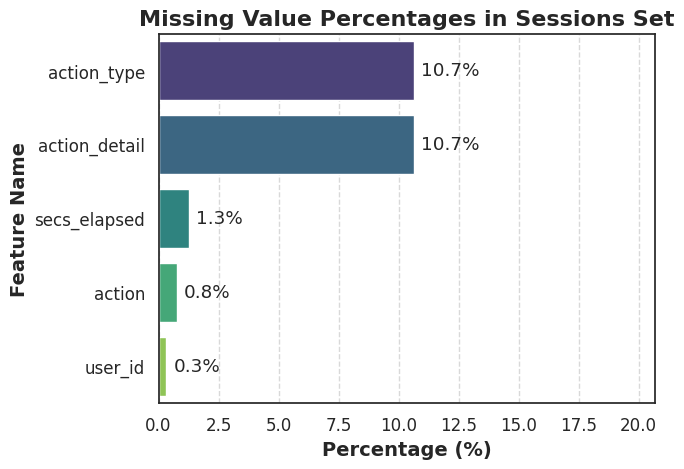

In [ ]:
ax = sns.barplot(
    data=missing_sessions_df,
    x='Missing Percentage',
    y='Feature',
    palette='viridis',
    hue='Feature'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5)

plt.xlim(0, max(missing_sessions_df['Missing Percentage']) + 10) # Extend the x-axis

plt.title("Missing Value Percentages in Sessions Set")
plt.xlabel("Percentage (%)")
plt.ylabel("Feature Name")
plt.show()

* Missing `user_id` should be dropped.
* Missing `secs_elapsed` can be imputed by 0 or NaN.

## 5.2. Duplicates

In [ ]:
sessions_df.duplicated().sum()

np.int64(252536)

* Duplicates should be dropped.

## 5.3. Outliers

In [ ]:
sessions_df['secs_elapsed'].describe()

,secs_elapsed
count,1.043171e+07
mean,1.940581e+04
std,8.888424e+04
min,0.000000e+00
25%,2.290000e+02
50%,1.147000e+03
75%,8.444000e+03
max,1.799977e+06


* `secs_elapsed` should be capped at 2 hours.

## 5.4. Univariate Analysis

===== Feature (action): =====
Missing Values: 79626 (0.75%)
------------------------------
Data Type: Categorical
Cardinality: 359


,Count,Percentage
action,,
show,2768278,26.195561
index,843699,7.983724
search_results,725226,6.862642
personalize,706824,6.688509
search,536057,5.072581
...,...,...
update_message,1,0.000009
acculynk_bin_check_failed,1,0.000009
host_cancel,1,0.000009


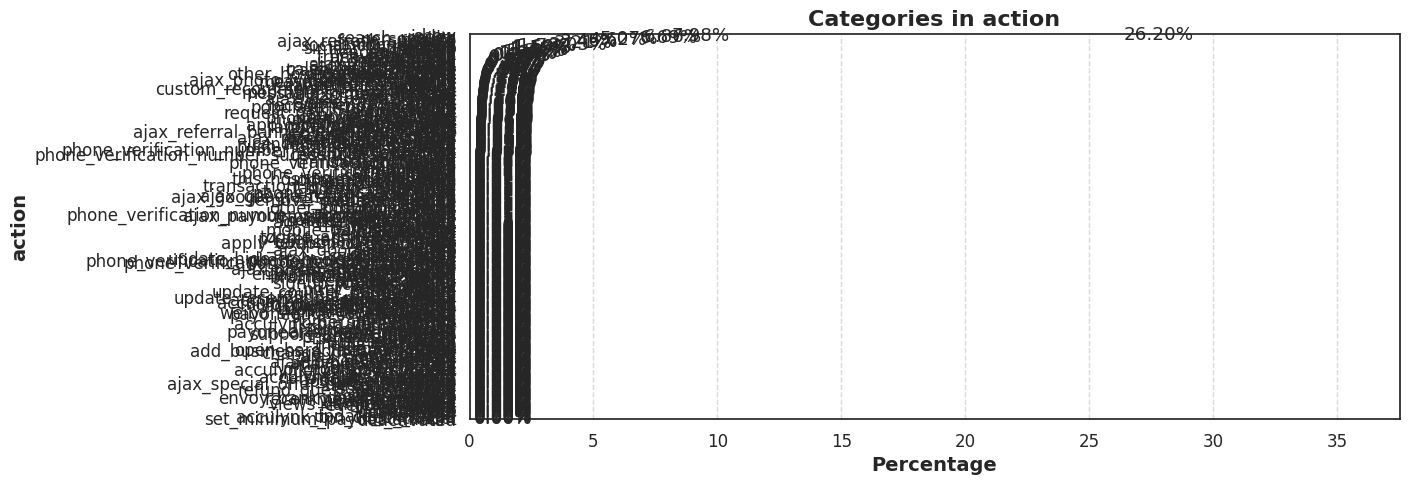



===== Feature (action_type): =====
Missing Values: 1126204 (10.66%)
------------------------------
Data Type: Categorical
Cardinality: 10


,Count,Percentage
action_type,,
view,3560902,33.695975
data,2103770,19.907479
click,1996183,18.889408
NaN,1126204,10.657003
-unknown-,1031170,9.757718
submit,623357,5.898680
message_post,87103,0.824235
partner_callback,19132,0.181042
booking_request,18773,0.177644


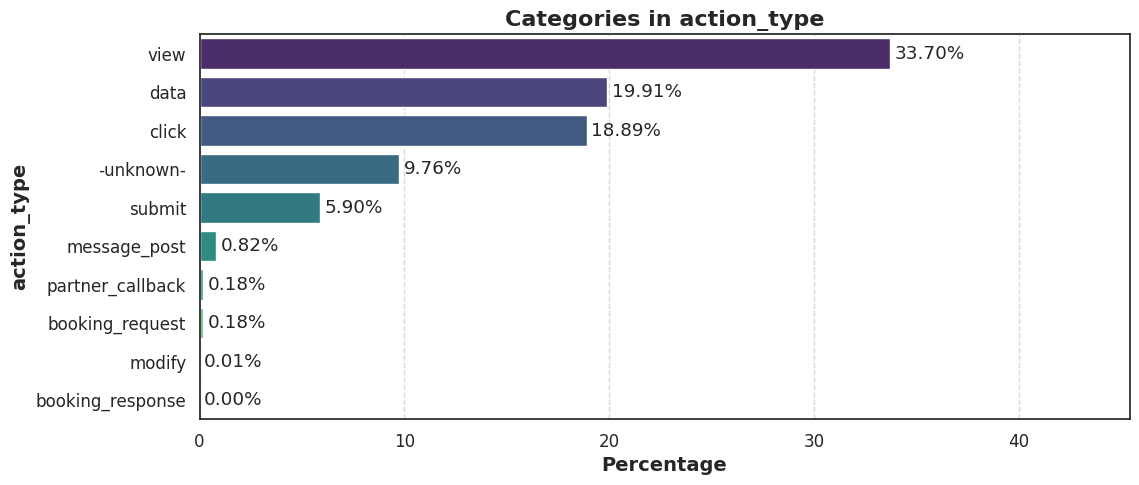



===== Feature (action_detail): =====
Missing Values: 1126204 (10.66%)
------------------------------
Data Type: Categorical
Cardinality: 155


,Count,Percentage
action_detail,,
view_search_results,1776885,16.814243
p3,1376550,13.025968
NaN,1126204,10.657003
-unknown-,1031141,9.757444
wishlist_content_update,706824,6.688509
...,...,...
special_offer_field,3,0.000028
tos_2014,2,0.000019
host_respond_page,2,0.000019


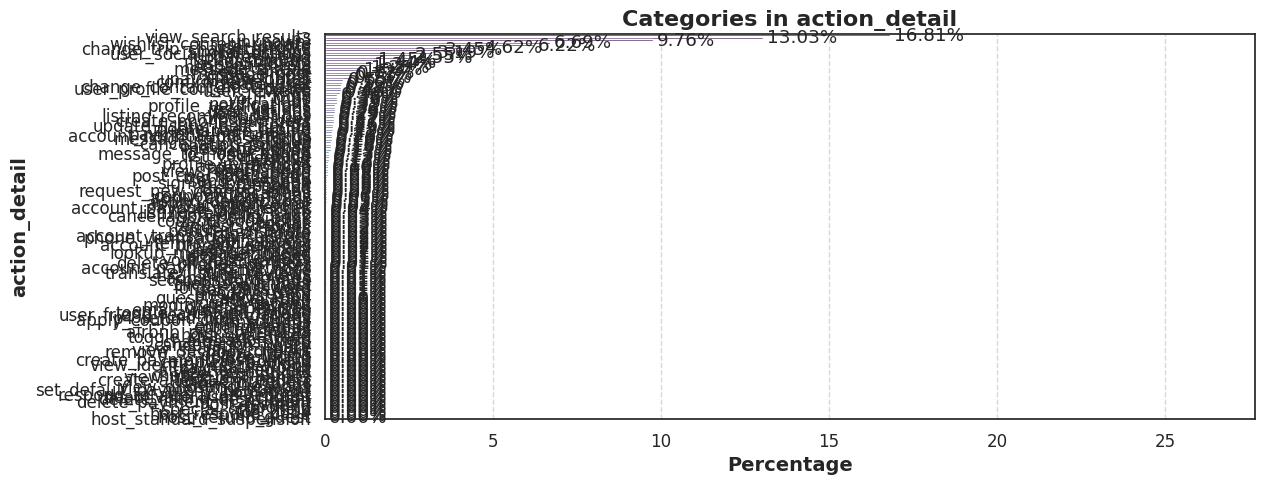



===== Feature (device_type): =====
Missing Values: 0 (0.00%)
------------------------------
Data Type: Categorical
Cardinality: 14


,Count,Percentage
device_type,,
Mac Desktop,3594286,34.011880
Windows Desktop,2658539,25.157127
iPhone,2105031,19.919411
Android Phone,839637,7.945287
iPad Tablet,683414,6.466985
Android App Unknown Phone/Tablet,273652,2.589504
-unknown-,211279,1.999283
Tablet,139886,1.323708
Linux Desktop,28373,0.268487


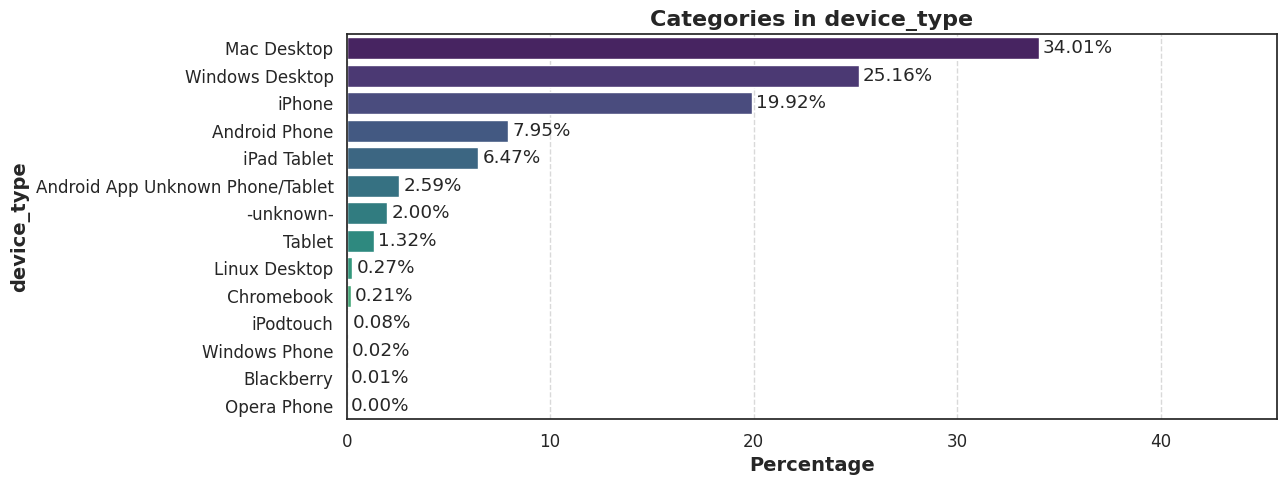

In [ ]:
for feature in sessions_df.columns:
    if feature not in ['user_id', 'secs_elapsed']:
        explore_feature(sessions_df, feature)

**High Cardinality:**
  * I will explore using `action_detail` or `action_type` and gitting rid of `action`.
  * The top 15 (10%) categories in `action_detail` can be pivotted and aggregated. The other categories can be merged into 'other' bucket.
  * `partner_callback` and `modify` can be merged into 'Other' bucket.

**Feature Engineering:**
  * Engagement Features:
    * total_time
    * total_actions
  * Device Features:
    * count_form_desktop: Total number of actions performed from desktop.
    * count_form_mobile: Total number of actions performed from mobile.
    * count_form_tablet: Total number of actions performed from tablet.
    * count_form_unknown: Total number of actions performed from unknown device.
  * OS Features:
    * count_os_apple: Total number of actions performed from Apple OS.
    * count_os_non-apple: Total number of actions performed from Non-Apple OS.
    * count_os_unknown: Total number of actions performed from unknown OS.

**Data Leakage:**
  * `booking_request` and `booking_response` in the feature `action_type` must be dropped.


## 5.5. Cramer's V Score (Correlation)

In [ ]:
sessions_df.columns

Index(['user_id', 'action', 'action_type', 'action_detail', 'device_type',
       'secs_elapsed'],
      dtype='object')

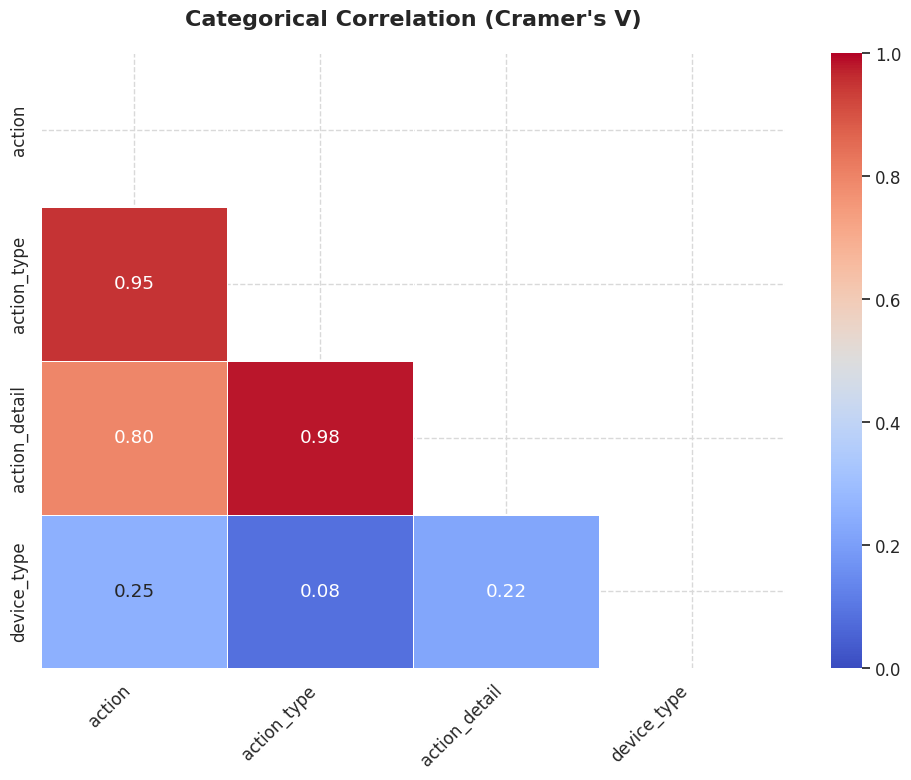

In [ ]:
carmer_vars = ['action', 'action_type', 'action_detail', 'device_type']

# 2. Create an empty DataFrame to hold the correlation matrix
cramers_matrix = pd.DataFrame(index=carmer_vars, columns=carmer_vars)

# 3. Calculate the association for every pair
for col1 in carmer_vars:
    for col2 in carmer_vars:
        cramers_matrix.loc[col1, col2] = cramers_v(sessions_df[col1], sessions_df[col2])

# Convert everything to float for plotting
cramers_matrix = cramers_matrix.astype(float)

# 4. Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cramers_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    mask=np.triu(np.ones_like(cramers_matrix, dtype=bool)) # Hides the upper triangle
)

plt.title("Categorical Correlation (Cramer's V)", pad=20, fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* `action` and `action_type` can be dropped, relying only on `action_detail`.

---

# 6. Preprocessing and Feature Engineering

## 6.1. Session Dataset Preprocessing

### 6.1.1. Clean Anomalies

In [ ]:
def clean_session_anomalies(df):
    """
    Cleans the sessions dataframe by dropping missing IDs, removing target leakage,
    dropping duplicates, and capping time outliers.
    """

    print("Cleaning Session Anomalies...")
    df_out = df.copy()

    # Drop rows wiht missing user_id
    df_out = df_out.dropna(subset=['user_id'])

    # Drop data leakage rows
    leakage_actions = ['booking_request', 'booking_response']
    df_out = df_out[~df_out['action_type'].isin(leakage_actions)]

    # Drop duplicates
    df_out = df_out.drop_duplicates()

    # Impute secs_elapsed with 0
    df_out['secs_elapsed'] = df_out['secs_elapsed'].fillna(0)

    # Cap secs_elapsed at 7200 seconds (2 hours)
    df_out['secs_elapsed'] = df_out['secs_elapsed'].clip(upper=7200)

    # Fill missing action_detail with '-unknown-'
    df_out['action_detail'] = df_out['action_detail'].fillna('-unknown-')

    return df_out

### 6.1.2. Categories Mapping

In [ ]:
def map_session_categories(df):
    """
    Maps device types to form factor and OS, buckets the action details,
    and drops redundant columns to prevent multicollinearity.
    """

    print("Mapping Session Categories...")
    df_out = df.copy()

    # Device Mapping (Desktop vs. Mobile vs. Tablet)
    device_map = {
        'Mac Desktop': 'Desktop', 'Windows Desktop': 'Desktop', 'Linux Desktop': 'Desktop', 'Chromebook': 'Desktop',
        'iPhone': 'Mobile', 'Android Phone': 'Mobile', 'Windows Phone': 'Mobile',
        'Blackberry': 'Mobile', 'Opera Phone': 'Mobile', 'iPodtouch': 'Mobile',
        'iPad Tablet': 'Tablet', 'Android App Unknown Phone/Tablet': 'Tablet', 'Tablet': 'Tablet',
        '-unknown-': 'Unknown'
    }
    df_out['device_form'] = df_out['device_type'].map(device_map)

    # 2. Device OS Mapping (Apple vs. Non-Apple)
    device_os_map = {
        'Mac Desktop': 'Apple', 'iPhone': 'Apple', 'iPad Tablet': 'Apple', 'iPodtouch': 'Apple',
        'Windows Desktop': 'Non-Apple', 'Android Phone': 'Non-Apple', 'Android App Unknown Phone/Tablet': 'Non-Apple',
        'Linux Desktop': 'Non-Apple', 'Chromebook': 'Non-Apple', 'Windows Phone': 'Non-Apple',
        'Blackberry': 'Non-Apple', 'Opera Phone': 'Non-Apple', 'Tablet': 'Non-Apple',
        '-unknown-': 'Unknown'
    }
    df_out['device_os'] = df_out['device_type'].map(device_os_map)

    # Action Detail Bucketing (Top 15 vs. 'Other')
    top_15_actions = df_out['action_detail'].value_counts().nlargest(15).index.tolist()

    df_out['action_detail_bucketed'] = np.where(
        df_out['action_detail'].isin(top_15_actions),
        df_out['action_detail'],
        'Other'
    )

    # Drop Redundant Columns
    cols_to_drop = ['action', 'action_type', 'action_detail', 'device_type']
    df_out = df_out.drop(columns=cols_to_drop)

    return df_out

### 6.1.3. Aggregation

In [ ]:
def aggregate_sessions(df):
    """
    Aggregates the session logs into one row per user.
    Calculates total time, total actions, and pivots categorical counts.
    """

    print("Aggregating Sessions...")

    # Group by user and calculate sum of time and count of actions
    agg_df = df.groupby('user_id').agg(
        total_time_spent=('secs_elapsed', 'sum'),
        total_actions=('user_id', 'count')
    )

    # Turn categories into individual columns counting the occurrences (Pivoting)
    form_counts = pd.crosstab(df['user_id'], df['device_form']).add_prefix('count_form_')
    os_counts = pd.crosstab(df['user_id'], df['device_os']).add_prefix('count_os_')
    detail_counts = pd.crosstab(df['user_id'], df['action_detail_bucketed']).add_prefix('count_detail_')

    # Concatination based on the user_id index
    final_sessions_df = pd.concat([agg_df, form_counts, os_counts, detail_counts], axis=1)

    # Fill any NaNs created during the pivot with 0 (for example, if a user never used a Mac)
    final_sessions_df = final_sessions_df.fillna(0)

    # Reset index so user_id becomes a standard column again before the final merge
    final_sessions_df = final_sessions_df.reset_index()

    return final_sessions_df

### 6.1.4. Master Session Preprocessing Function

In [ ]:
def preprocess_sessions(raw_df):
    """
    Master orchestrator function for the Sessions dataset.
    Executes the cleaning, mapping, and aggregating steps.
    """

    # Clean anomalies, drop leakage, and cap time
    df_cleaned = clean_session_anomalies(raw_df)

    # Map devices and bucket action categories
    df_mapped = map_session_categories(df_cleaned)

    # Aggregate and pivot into one row per user
    df_final = aggregate_sessions(df_mapped)

    print(f"--- Sessions Preprocessing Complete. Output shape: {df_final.shape} ---")

    return df_final

In [ ]:
processed_sessions_df = preprocess_sessions(sessions_df)

Cleaning Session Anomalies...
Mapping Session Categories...
Aggregating Sessions...
--- Sessions Preprocessing Complete. Output shape: (135440, 26) ---


In [ ]:
processed_sessions_df.head()

,user_id,total_time_spent,total_actions,count_form_Desktop,count_form_Mobile,count_form_Tablet,count_form_Unknown,count_os_Apple,count_os_Non-Apple,count_os_Unknown,...,count_detail_listing_reviews,count_detail_message_thread,count_detail_p3,count_detail_similar_listings,count_detail_update_listing,count_detail_user_profile,count_detail_user_social_connections,count_detail_user_wishlists,count_detail_view_search_results,count_detail_wishlist_content_update
0,00023iyk9l,88141.0,39,35,4,0,0,39,0,0,...,0,0,6,3,0,0,0,0,5,4
1,0010k6l0om,144707.0,62,62,0,0,0,62,0,0,...,0,0,13,0,0,0,0,0,10,8
2,001wyh0pz8,179723.0,89,0,0,89,0,0,89,0,...,0,0,2,0,0,2,2,4,65,0
3,0028jgx1x1,98392.0,31,0,1,0,30,0,1,30,...,5,0,9,0,0,6,0,0,9,0
4,002qnbzfs5,1521738.0,740,0,726,0,14,726,0,14,...,10,0,25,0,0,75,68,0,124,0


In [ ]:
print(f"Training data shape: {train_df.shape}")
print(f"Processed session data shape: {processed_sessions_df.shape}")

Training data shape: (213451, 16)
Processed session data shape: (135440, 26)


* The processed session data has fewer rows than the training dataset because the session data only dates back to 1/1/2014, while the training dataset dates back to 2010.

In [ ]:
missing_sessions_mask = ~train_df['id'].isin(processed_sessions_df['user_id'])

num_missing = missing_sessions_mask.sum()
total_users = len(train_df)
percent_missing = (num_missing / total_users) * 100

print(f"Total users in training set: {total_users:,}")
print(f"Users without session logs: {num_missing:,}")
print(f"Percentage of missing session data: {percent_missing:.1f}%")

Total users in training set: 213,451
Users without session logs: 139,676
Percentage of missing session data: 65.4%


I will test the two apporoaches during modelling:
  1. Using the full training dataset while adding a `has_session_data` feature to indicate whether the user has a sesssion data or not. This feature will help tree-based models.
  2. Dropping the users without session data from the trainig dataset.

## 6.2. Demographic Data Preprocessing

### 6.2.1. Clean Anomalies

In [ ]:
def clean_user_anomalies(df):
    """
    Cleans the demographic data by dropping target leakage,
    fixing age typos, and handling missing values.
    """

    print("Cleaning Demographic Data Anomalies...")
    df_out = df.copy()

    # Drop Data Leakage
    if 'date_first_booking' in df_out.columns:
        df_out = df_out.drop(columns=['date_first_booking'])

    # Replace the birth year with the age
    df_out.loc[df_out['age'] > 1900, 'age'] = 2014 - df_out['age']

    # Any age outside 15 to 89 becomes NaN
    df_out.loc[(df_out['age'] < 15) | (df_out['age'] > 89), 'age'] = np.nan

    # Fill teh missing gender with '-unknown-'
    df_out['gender'] = df_out['gender'].fillna('-unknown-')

    # Fill teh missing first_affiliate_tracked with '-unknown-'
    df_out['first_affiliate_tracked'] = df_out['first_affiliate_tracked'].fillna('-unknown-')

    return df_out

### 6.2.2. Time Feature Extraction

In [ ]:
def extract_time_features(df):
    """
    Parses date strings into datetime objects, extracts seasonality features,
    calculates time between first action and account creation, and drops the raw dates.
    """

    print("Extract ing Time Features...")
    df_out = df.copy()

    # Date Parsing
    df_out['date_account_created'] = pd.to_datetime(df_out['date_account_created'])

    df_out['timestamp_first_active'] = pd.to_datetime(
        df_out['timestamp_first_active'],
        format='%Y%m%d%H%M%S'
    )

    # Temporal Feature Extraction (Seasonality)
    # Month captures seasonal vacation planning
    # Day of week captures weekend vs weekday behavioral differences
    df_out['account_created_month'] = df_out['date_account_created'].dt.month
    df_out['account_created_day'] = df_out['date_account_created'].dt.day
    df_out['account_created_dayofweek'] = df_out['date_account_created'].dt.dayofweek

    # How many days did they browse anonymously before finally signing up?
    df_out['days_since_first_active'] = (df_out['date_account_created'] - df_out['timestamp_first_active']).dt.days

    # Remove the Raw Dates
    df_out = df_out.drop(columns=['date_account_created', 'timestamp_first_active'])

    return df_out

### 6.2.3. Demographic Categories Mapping

In [ ]:
def map_user_categories(df):
    """
    Buckets high-cardinality categorical variables, isolates high-intent signals,
    and creates boolean indicators for device types.
    """


    print("Mapping User Categories...")
    df_out = df.copy()

    # Device Booleans
    apple_devices = ['Mac Desktop', 'iPad', 'iPhone']
    df_out['is_Apple_device'] = df_out['first_device_type'].isin(apple_devices).astype(int)
    df_out['is_desktop'] = df_out['first_device_type'].str.contains('Desktop', na=False).astype(int)

    # Bucketing
    df_out['channel_intent'] = np.where(df_out['affiliate_channel'].isin(['seo', 'direct', 'sem-brand', 'other']), 'High_Intent',
                               np.where(df_out['affiliate_channel'] == 'sem-non-brand', 'Mid_Intent', 'Low_Intent'))

    df_out['provider_intent'] = np.where(df_out['affiliate_provider'].isin(['craigslist', 'direct', 'google']), 'High_Intent',
                                np.where(
                                    df_out['affiliate_provider'].isin(['other', 'bing', 'yahoo', 'facebook', 'naver', 'baidu', 'padmapper', 'vast']),
                                    'Mid_Intent',
                                    'Low_Intent'
                                ))

    df_out['signup_flow'] = df_out['signup_flow'].astype(str)
    df_out['flow_intent'] = np.where(df_out['signup_flow'] == '0', 'Flow_0',
                            np.where(df_out['signup_flow'].isin(['3', '2']), 'High_Intent',
                            np.where(df_out['signup_flow'].isin(['24', '12', '25', '23']), 'Low_Intent',
                            np.where(df_out['signup_flow'].isin(['1', '4', '5', '6', '8', '10', '15', '16', '20', '21']), 'Rare_Flow', 'Other_Flow'))))

    # Long-tail merging
    keep_tracked = ['untracked', 'linked', 'omg', '-unknown-']
    df_out['first_affiliate_tracked'] = np.where(
        df_out['first_affiliate_tracked'].isin(keep_tracked),
        df_out['first_affiliate_tracked'],
        'other'
    )

    top_browsers = ['Chrome', 'Safari', 'Firefox', '-unknown-', 'IE', 'Mobile Safari']
    df_out['first_browser'] = np.where(
        df_out['first_browser'].isin(top_browsers),
        df_out['first_browser'],
        'Other'
    )

    top_langs = ['en', 'fr', 'es', 'de', 'it', 'nl', 'pt']
    df_out['language'] = np.where(
        df_out['language'].isin(top_langs),
        df_out['language'],
        'Other'
    )

    # Age Bucketing
    bins = [14, 24, 34, 44, 49, 150]
    labels = ['15-24', '25-34', '35-44', '45-49', '50+']
    df_out['age_bucket'] = pd.cut(df_out['age'], bins=bins, labels=labels)
    df_out['age_bucket'] = df_out['age_bucket'].astype(str).replace('nan', '-unknown-')

    # Remove redundant columns
    cols_to_drop = ['affiliate_channel', 'affiliate_provider', 'signup_flow', 'first_device_type']
    df_out = df_out.drop(columns=cols_to_drop)

    return df_out



### 6.2.4. Master User Data Preprocessing Function

In [ ]:
def preprocess_users(raw_df):
    """
    Master orchestrator pipeline for preprocessing the user demographic dataset.
    Clean anomalies, extract temporal features, and map categorical variables.
    """
    df_cleaned = clean_user_anomalies(raw_df)
    df_timed = extract_time_features(df_cleaned)
    df_mapped = map_user_categories(df_timed)

    print(f"--- Users Preprocessing Complete. Output shape: {df_mapped.shape} ---")

    return df_mapped

In [ ]:
processed_users_df = preprocess_users(train_df)

Cleaning Demographic Data Anomalies...
Extract ing Time Features...
Mapping User Categories...
--- Users Preprocessing Complete. Output shape: (213451, 19) ---


In [ ]:
processed_users_df.head()

,id,gender,age,signup_method,language,first_affiliate_tracked,signup_app,first_browser,country_destination,account_created_month,account_created_day,account_created_dayofweek,days_since_first_active,is_Apple_device,is_desktop,channel_intent,provider_intent,flow_intent,age_bucket
0,gxn3p5htnn,-unknown-,NaN,facebook,en,untracked,Web,Chrome,NDF,6,28,0,465,1,1,High_Intent,High_Intent,Flow_0,-unknown-
1,820tgsjxq7,MALE,38.0,facebook,en,untracked,Web,Chrome,NDF,5,25,2,731,1,1,High_Intent,High_Intent,Flow_0,35-44
2,4ft3gnwmtx,FEMALE,56.0,basic,en,untracked,Web,IE,US,9,28,1,475,0,1,High_Intent,High_Intent,High_Intent,50+
3,bjjt8pjhuk,FEMALE,42.0,facebook,en,untracked,Web,Firefox,other,12,5,0,764,1,1,High_Intent,High_Intent,Flow_0,35-44
4,87mebub9p4,-unknown-,41.0,basic,en,untracked,Web,Chrome,US,9,14,1,279,1,1,High_Intent,High_Intent,Flow_0,35-44


## 6.3. Mergeg Session Data

In [ ]:
session_features = processed_sessions_df.columns.drop(['user_id', 'index'], errors='ignore')

In [ ]:
# Approach 1: Remove users without session data
filtered_dataset = pd.merge(
    processed_users_df,
    processed_sessions_df,
    left_on='id',
    right_on='user_id',
    how='inner'
)

# Deop ID columns
filtered_dataset = filtered_dataset.drop(columns=['user_id', 'index'], errors='ignore')

In [ ]:
# Approach 1: Use full dataset and add a new feature to flag missing session data
full_dataset = pd.merge(
    processed_users_df,
    processed_sessions_df,
    left_on='id',
    right_on='user_id',
    how='left'
)
full_dataset['has_session_data'] = full_dataset['total_actions'].notna().astype(int)

# Fill the empty session features with -1
full_dataset[session_features] = full_dataset[session_features].fillna(-1)

# Deop ID columns
full_dataset = full_dataset.drop(columns=['user_id', 'index'], errors='ignore')

In [ ]:
print(f"Filtered Dataset Shape: {filtered_dataset.shape}")
print(f"Full Dataset Shape: {full_dataset.shape}")

Filtered Dataset Shape: (73775, 44)
Full Dataset Shape: (213451, 45)


# 7. Dataset Experiments

## 7.1. Label Encoding

In [ ]:
label_encoder = LabelEncoder()
label_encoder.fit(full_dataset['country_destination'])

LabelEncoder()

In [ ]:
y_a = label_encoder.transform(filtered_dataset['country_destination'])
X_a = filtered_dataset.drop(columns=['country_destination', 'id'], errors='ignore')

In [ ]:
y_b = label_encoder.transform(full_dataset['country_destination'])
X_b = full_dataset.drop(columns=['country_destination', 'id'], errors='ignore')

## 7.2. One-Hot Encoding

In [ ]:
X_a = pd.get_dummies(X_a)
X_b = pd.get_dummies(X_b)

## 7.3. Train/Validation Splits

In [ ]:
Xa_train, Xa_val, ya_train, ya_val = train_test_split(
    X_a,
    y_a,
    test_size=0.2,
    random_state=42,
    stratify=y_a
)
Xb_train, Xb_val, yb_train, yb_val = train_test_split(
    X_b,
    y_b,
    test_size=0.2,
    random_state=42,
    stratify=y_b
)

## 7.4. Evaluation Function

In [ ]:
def evaluate_ndcg(y_true, y_pred_proba, k=5):
    """
    Calculates the NDCG@k metric.
    """
    # Get the indices of the top k probabilities for each user
    top_k_preds = np.argsort(y_pred_proba, axis=1)[:, -k:][:, ::-1]

    # Create the  discount array
    ranks = np.arange(1, k + 1)
    discounts = 1 / np.log2(ranks + 1)

    # Find where the true label matches the top k predictions
    hits = (top_k_preds == y_true[:, np.newaxis])

    # 4. Multiply hits by discounts and sum the rows to get the score per user
    user_scores = np.sum(hits * discounts, axis=1)

    # Return the mean score across the whole dataset
    return np.mean(user_scores)

## 7.4. Training Baseline Models

In [ ]:
# Train and Evaluate the Filtered Dataset
rf_a = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_a.fit(Xa_train, ya_train)

proba_a_train = rf_a.predict_proba(Xa_train)
proba_a_val = rf_a.predict_proba(Xa_val)

score_a_train = evaluate_ndcg(ya_train, proba_a_train)
score_a_val = evaluate_ndcg(ya_val, proba_a_val)

print("===== Filtered Dataset =====")
print(f"Train NDCG@5:      {score_a_train:.4f}")
print(f"Validation NDCG@5: {score_a_val:.4f}")

# Train and Evaluate teh Full Dataset
rf_b = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_b.fit(Xb_train, yb_train)
proba_b_train = rf_b.predict_proba(Xb_train)
proba_b_val = rf_b.predict_proba(Xb_val)

score_b_train = evaluate_ndcg(yb_train, proba_b_train)
score_b_val = evaluate_ndcg(yb_val, proba_b_val)

print("===== Full Dataset =====")
print(f"Train NDCG@5:      {score_b_train:.4f}")
print(f"Validation NDCG@5: {score_b_val:.4f}")

===== Filtered Dataset =====
Train NDCG@5:      0.9999
Validation NDCG@5: 0.8398
===== Full Dataset =====
Train NDCG@5:      0.9881
Validation NDCG@5: 0.8054


* Quality over quantity: The filtered dataset containing only users with session data outperforms the full data.
* The session features are strong predictors.
* However, both experiments leads to significant overfitting which will be treated later.

## 7.5. Feature Importance

In [ ]:
def plot_feature_importance(model, feature_names, top_n=20):
    """
    Extracts and plots the top N feature importances from a tree-based model.
    """

    importances = model.feature_importances_

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    importance_df = importance_df.sort_values(by='Importance', ascending=False).head(top_n)

    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=importance_df,
        x='Importance',
        y='Feature',
        palette='viridis',
        hue='Feature',
        legend=False
    )

    plt.title(f"Top {top_n} Feature Importances")
    plt.xlabel("Relative Importance (Gini)")
    plt.ylabel("Feature")

    ax = plt.gca()
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=5)

    plt.xlim(0, importance_df['Importance'].max() * 1.15)
    plt.tight_layout()
    plt.show()


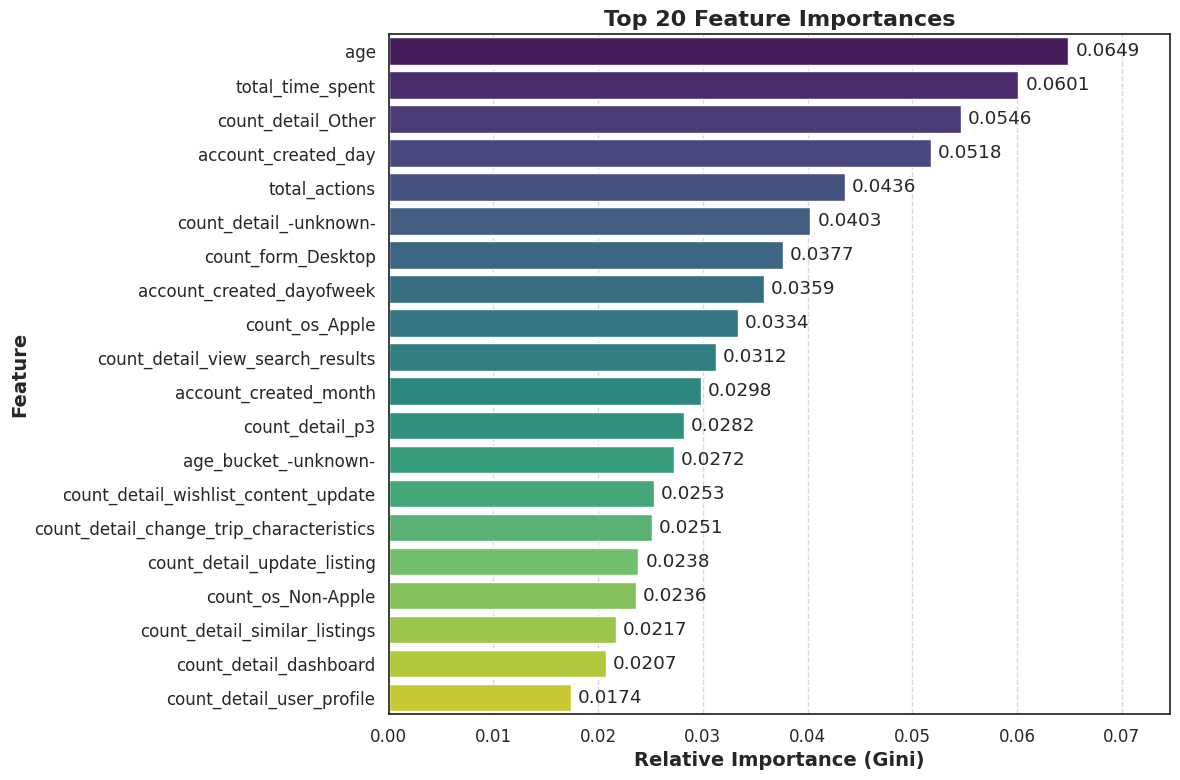

In [ ]:
plot_feature_importance(model=rf_a, feature_names=Xa_train.columns, top_n=20)

# 8. Model Selection

* Tree-based models are prefered as they can handle high-dimensionality and sparsity.
* Filtered dataset will be used during model selection experiments.

## 8.1. XGBoost

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

In [ ]:
xgb_model.fit(Xa_train, ya_train)

proba_xgb_train = xgb_model.predict_proba(Xa_train)
proba_xgb_val = xgb_model.predict_proba(Xa_val)

score_xgb_train = evaluate_ndcg(ya_train, proba_xgb_train)
score_xgb_val = evaluate_ndcg(ya_val, proba_xgb_val)

print(f"===== XGBoost Results =====")
print(f"Train NDCG@5:      {score_xgb_train:.4f}")
print(f"Validation NDCG@5: {score_xgb_val:.4f}")

===== XGBoost Results =====
Train NDCG@5:      0.8723
Validation NDCG@5: 0.8471


* XGB acheived a higher valiadtion NDCG@5 (0.8471) than the random forest (0.8398)
* Compared to Random Forest, XGB reduced the overfitting gap from 0.1601 to 0.0252

## 8.2. LightGBM

In [ ]:
lgbm_model = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

In [ ]:
lgbm_model.fit(Xa_train, ya_train)

proba_lgbm_train = lgbm_model.predict_proba(Xa_train)
proba_lgbm_val = lgbm_model.predict_proba(Xa_val)

score_lgbm_train = evaluate_ndcg(ya_train, proba_lgbm_train)
score_lgbm_val = evaluate_ndcg(ya_val, proba_lgbm_val)

print(f"===== LGBM Results =====")
print(f"Train NDCG@5:      {score_lgbm_train:.4f}")
print(f"Validation NDCG@5: {score_lgbm_val:.4f}")

===== LGBM Results =====
Train NDCG@5:      0.8848
Validation NDCG@5: 0.8467


* The validation NDCG@5 of LGBM is slightly lower than XGB and the overfitting gap slightly increased.

## 8.3. CatBoost

In [ ]:
cat_model = CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    random_seed=42,
    thread_count=-1,
    verbose=0,
    loss_function='MultiClass'
)

In [ ]:
cat_model.fit(Xa_train, ya_train)

proba_cat_train = cat_model.predict_proba(Xa_train)
proba_cat_val = cat_model.predict_proba(Xa_val)

score_cat_train = evaluate_ndcg(ya_train, proba_cat_train)
score_cat_val = evaluate_ndcg(ya_val, proba_cat_val)

print(f"===== CatBoost Results =====")
print(f"Train NDCG@5:      {score_cat_train:.4f}")
print(f"Validation NDCG@5: {score_cat_val:.4f}")

===== CatBoost Results =====
Train NDCG@5:      0.8506
Validation NDCG@5: 0.8466


* Although CatBoost has the smallest overfitting gap so far (0.004), the XGB Validation NDCG@5 is slightly higher.

# 9. Hyperparameter Tuning

## 9.1. Class Weight

In [ ]:
weighted_xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

In [ ]:
sample_weights = compute_sample_weight(class_weight='balanced', y=ya_train)

weighted_xgb_model.fit(Xa_train, ya_train, sample_weight=sample_weights)

proba_weighted_xgb_train = weighted_xgb_model.predict_proba(Xa_train)
proba_weighted_xgb_val = weighted_xgb_model.predict_proba(Xa_val)

score_weighted_xgb_train = evaluate_ndcg(ya_train, proba_weighted_xgb_train)
score_weighted_xgb_val = evaluate_ndcg(ya_val, proba_weighted_xgb_val)

print(f"===== Weighted XGBoost Results =====")
print(f"Train NDCG@5:      {score_weighted_xgb_train:.4f}")
print(f"Validation NDCG@5: {score_weighted_xgb_val:.4f}")

===== Weighted XGBoost Results =====
Train NDCG@5:      0.7065
Validation NDCG@5: 0.6381


* Class weight ruined the predictions because the model focused on predicting tiny class and ignored the `NDF` and `US` classes.

## 9.2. Randomized Search

In [ ]:
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'subsample': [0.6, 0.8, 1],
    'n_estimators': [80, 100, 150]
}

In [ ]:
ndcg_scorer = make_scorer(evaluate_ndcg, response_method='predict_proba')

tuned_xgb = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=10,
    scoring=ndcg_scorer,
    cv=3,
    verbose=3
)

tuned_xgb.fit(Xa_train, ya_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV 1/3] END learning_rate=0.3, max_depth=8, n_estimators=80, subsample=1;, score=0.841 total time=  23.0s
[CV 2/3] END learning_rate=0.3, max_depth=8, n_estimators=80, subsample=1;, score=0.842 total time=  16.8s
[CV 3/3] END learning_rate=0.3, max_depth=8, n_estimators=80, subsample=1;, score=0.842 total time=  18.3s
[CV 1/3] END learning_rate=0.01, max_depth=4, n_estimators=100, subsample=1;, score=0.828 total time=  14.0s
[CV 2/3] END learning_rate=0.01, max_depth=4, n_estimators=100, subsample=1;, score=0.827 total time=  13.7s
[CV 3/3] END learning_rate=0.01, max_depth=4, n_estimators=100, subsample=1;, score=0.827 total time=  14.8s
[CV 1/3] END learning_rate=0.3, max_depth=4, n_estimators=100, subsample=0.6;, score=0.843 total time=  14.7s
[CV 2/3] END learning_rate=0.3, max_depth=4, n_estimators=100, subsample=0.6;, score=0.843 total time=  13.3s
[CV 3/3] END learning_rate=0.3, max_depth=4, n_estimators=100, subsampl

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=-1,
                                           num_parallel_tree=None, ...),
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1, 0.3],
                                        'max_depth': [4, 6, 8],
                                        'n_estimators': [80, 100, 150],
                                        'subsample': [0.6, 0.8, 1]},
                   scoring=make_scorer(evaluate_ndcg, response_method='predict_proba'),
                   verbose=3)

In [ ]:
proba_tuned_xgb_val = tuned_xgb.predict_proba(Xa_val)
score_tuned_xgb_val = evaluate_ndcg(ya_val, proba_tuned_xgb_val)

print(f"Best Parameters: {tuned_xgb.best_params_}")
print(f"===== Tuned XGBoost Results =====")
print(f"Validation NDCG@5: {score_tuned_xgb_val:.4f}")

Best Parameters: {'subsample': 0.8, 'n_estimators': 150, 'max_depth': 8, 'learning_rate': 0.05}
===== Tuned XGBoost Results =====
Validation NDCG@5: 0.8477


* Hyperparameter tuning increased the validation NDCG@5 slightly by 0.0006.

# 10. Error Analysis

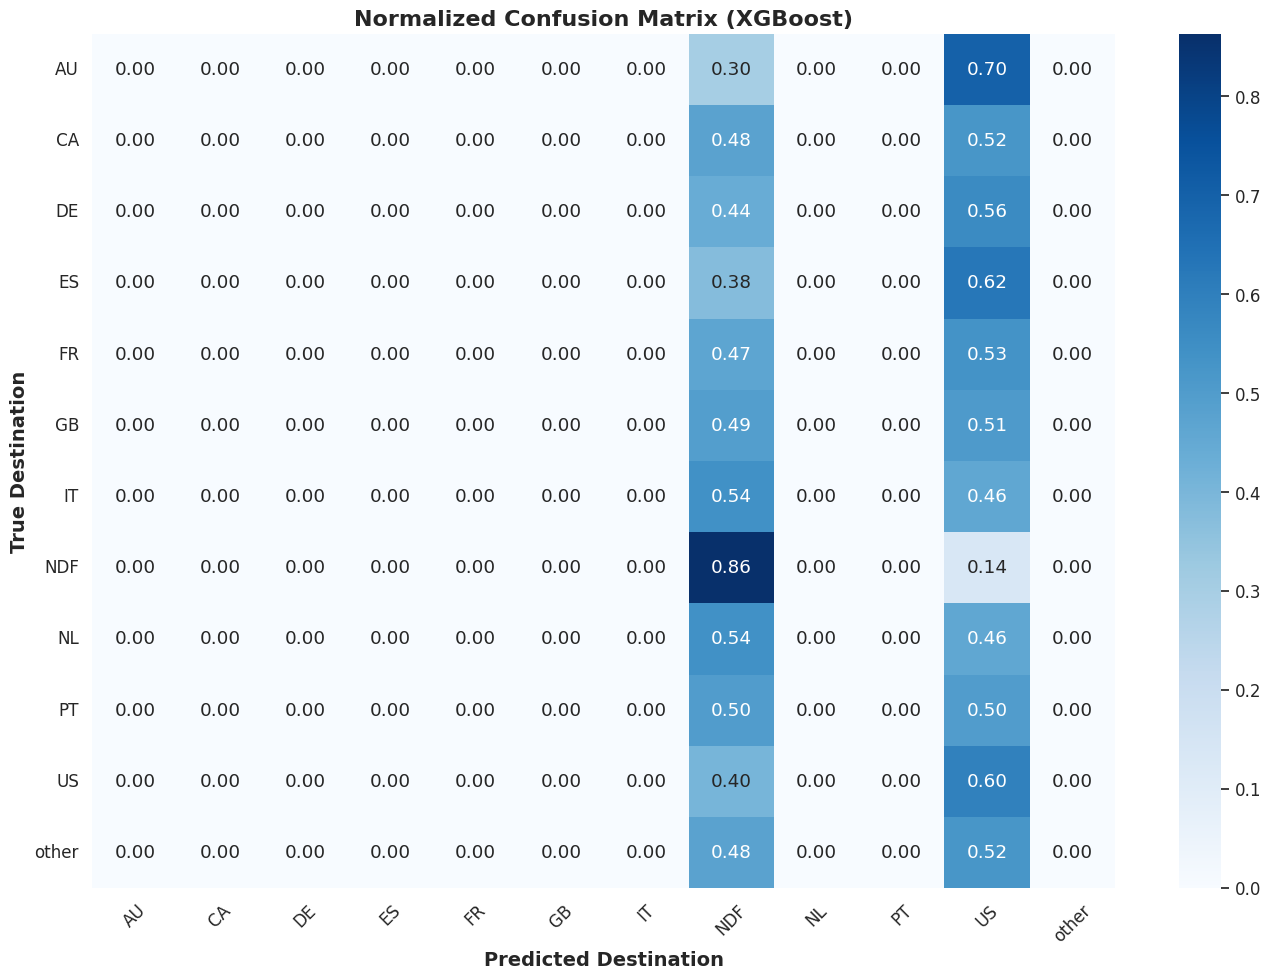

In [ ]:
y_pred_val = tuned_xgb.predict(Xa_val)

cm = confusion_matrix(ya_val, y_pred_val)

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14, 10))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Normalized Confusion Matrix (XGBoost)")
plt.ylabel("True Destination")
plt.xlabel("Predicted Destination")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

* Although the model has a good NDCG@5, it only predicts `NDF` and `US`.

# 11. Final Pipeline

In [ ]:
# raw_features = filtered_dataset.drop(columns=['country_destination', 'id', 'date_first_booking'], errors='ignore')
# categorical_cols = raw_features.columns.tolist()

In [ ]:
# # Preprocessor
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
#     ])

In [ ]:
# # Pipeline
# pipeline = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('classifier', XGBClassifier(
#         n_estimators=100,
#         max_depth=6,
#         learning_rate=0.1,
#         random_state=42,
#         n_jobs=-1
#     ))
# ])


In [ ]:
# pipeline.fit(raw_features, y_a)

# 12. Generate Submission

In [ ]:
def generate_submission(model, X_train_ref, label_encoder, test_path='test_users.csv', output_name='submission.csv'):
    """
    Automated pipeline to generate a submission file.
    """

    # Load the data
    test_df = pd.read_csv(test_path)
    test_ids = test_df['id']

    # Preprocessing
    print("Preprocessing and Aligning columns...")
    X_test = test_df.drop(columns=['id', 'date_first_booking'], errors='ignore')
    X_test = pd.get_dummies(X_test)

    # Alignment to Avoid the Dummy Variable Trap
    _, X_test_aligned = X_train_ref.align(X_test, join='left', axis=1, fill_value=0)

    # Predict Probabilities
    print("Generating predictions...")
    proba_test = model.predict_proba(X_test_aligned)

    # Extract Top 5 Indices
    top_5_indices = np.argsort(proba_test, axis=1)[:, -5:][:, ::-1]

    # Vectorized Formatting
    print("Formatting 5 rows (ranks) per user ...")
    ids_array = np.repeat(test_ids.values, 5)

    # Flatten 2D matrix into a 1D list so the encoder can translate them all at once
    countries_array = label_encoder.inverse_transform(top_5_indices.flatten())

    # Save to CSV
    submission_df = pd.DataFrame({'id': ids_array, 'country': countries_array})
    submission_df.to_csv(output_name, index=False)

    print(f"File saved as '{output_name}'")




In [ ]:
generate_submission(
    model=tuned_xgb,
    X_train_ref=Xa_train,
    label_encoder=label_encoder,
    output_name='tuned_xgb.csv'
)

Preprocessing and Aligning columns...
Generating predictions...
Formatting 5 rows (ranks) per user ...
File saved as 'tuned_xgb.csv'


In [ ]:
!kaggle competitions submit -c airbnb-recruiting-new-user-bookings -f tuned_xgb.csv  -m "Tuned XGB"

100% 4.38M/4.38M [00:00<00:00, 9.94MB/s]
Successfully submitted to Airbnb New User Bookings

# 13. Kaggle Public Score

* Default XGBoost: 0.86452
* Tuned XGBoost: 0.86345

---